# XZ particle-representation sensitivity study

## Purpose

Notebook 12 compared two operation orders using labelled XYZ particle
coordinates:

1. DEM particles → coarse-graining → continuum POD;
2. DEM particles → particle-coordinate POD → coarse-graining.

This notebook tests whether the poor particle-first result was caused partly by
including the transverse \(y\)-coordinate, even though the downstream continuum
field depends only on \(x\) and \(z\).

For every parameter case independently, the first stationary drum cycle will
again train the POD basis and the second cycle will provide blocked validation.
The ranks, comparison times, particle species, continuum grid and
coarse-graining configuration will remain unchanged.

The XZ particle-first results will be compared with the saved XYZ particle-first
and continuum-first results from Notebook 12.

This is a representation-sensitivity experiment using oracle orthogonal
projection. It is not a temporal forecast or parameter-prediction experiment.
No raw multi-gigabyte particle file will be scanned.

In [2]:
from pathlib import Path
import hashlib
import json
import sys

import numpy as np
import pandas as pd
from IPython.display import display


# Support launching Jupyter from either the repository root
# or the notebooks directory.
REPO_ROOT = Path.cwd().resolve()

if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

if not (REPO_ROOT / "results").is_dir():
    raise RuntimeError(
        "Repository root could not be identified. "
        f"Current directory: {Path.cwd().resolve()}"
    )


NOTEBOOK_12_TABLE_DIRECTORY = (
    REPO_ROOT
    / "results"
    / "tables"
    / "multi_parameter_route_order"
)

MULTI_PARAMETER_CACHE_DIRECTORY = (
    REPO_ROOT
    / "data"
    / "interim"
    / "multi_parameter_route_order"
)

PILOT_COMPACT_PATH = (
    REPO_ROOT
    / "data"
    / "interim"
    / "particle_positions_ratio_1_000000_num_1.npz"
)

PILOT_COMPACT_MANIFEST_PATH = (
    REPO_ROOT
    / "results"
    / "tables"
    / "particle_snapshot_representation_ratio_1_000000_num_1.json"
)

PILOT_CG_PATH = (
    REPO_ROOT
    / "data"
    / "raw"
    / "CG_field_phi_small"
    / "rotating_drum_bidisperse_size_ratio_1_000000_num_1.stat"
)

AGGREGATE_MANIFEST_PATH = (
    NOTEBOOK_12_TABLE_DIRECTORY
    / "multi_parameter_route_order_manifest.json"
)


XZ_CACHE_DIRECTORY = (
    REPO_ROOT
    / "data"
    / "interim"
    / "xz_particle_representation_sensitivity"
)

XZ_TABLE_DIRECTORY = (
    REPO_ROOT
    / "results"
    / "tables"
    / "xz_particle_representation_sensitivity"
)

XZ_FIGURE_DIRECTORY = (
    REPO_ROOT
    / "results"
    / "figures"
    / "xz_particle_representation_sensitivity"
)

for directory in [
    XZ_CACHE_DIRECTORY,
    XZ_TABLE_DIRECTORY,
    XZ_FIGURE_DIRECTORY,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


SELECTED_RANKS = (
    0,
    8,
    14,
    27,
    100,
)

STATIONARY_TIME_MIN = 1377.0
COMPARISON_TIME_MAX = 1720.72

LUCY_CUTOFF = 3.0
AXIAL_AVERAGING_LENGTH = 10.0
SMALL_SPECIES = 1

PHYSICAL_NEGATIVE_TOLERANCE = -1e-4


required_inputs = pd.DataFrame(
    [
        {
            "input": "Notebook 12 table directory",
            "path": NOTEBOOK_12_TABLE_DIRECTORY,
        },
        {
            "input": "Notebook 12 aggregate manifest",
            "path": AGGREGATE_MANIFEST_PATH,
        },
        {
            "input": "pilot compact particle artifact",
            "path": PILOT_COMPACT_PATH,
        },
        {
            "input": "pilot compact manifest",
            "path": PILOT_COMPACT_MANIFEST_PATH,
        },
        {
            "input": "reference MercuryCG field",
            "path": PILOT_CG_PATH,
        },
        {
            "input": "multi-parameter compact directory",
            "path": MULTI_PARAMETER_CACHE_DIRECTORY,
        },
    ]
)

required_inputs["exists"] = [
    path.exists()
    for path in required_inputs["path"]
]


print("Python:", sys.version.split()[0])
print("Repository root:", REPO_ROOT)

display(
    required_inputs.assign(
        path=required_inputs["path"].astype(str)
    )
)

assert required_inputs["exists"].all()
assert SELECTED_RANKS == (0, 8, 14, 27, 100)

print(
    "Preflight paths exist:",
    bool(required_inputs["exists"].all()),
)

Python: 3.12.1
Repository root: /Users/rallen/Documents/msc-rom-particle-systems


,input,path,exists
0,Notebook 12 table directory,/Users/rallen/Documents/msc-rom-particle-syste...,True
1,Notebook 12 aggregate manifest,/Users/rallen/Documents/msc-rom-particle-syste...,True
2,pilot compact particle artifact,/Users/rallen/Documents/msc-rom-particle-syste...,True
3,pilot compact manifest,/Users/rallen/Documents/msc-rom-particle-syste...,True
4,reference MercuryCG field,/Users/rallen/Documents/msc-rom-particle-syste...,True
5,multi-parameter compact directory,/Users/rallen/Documents/msc-rom-particle-syste...,True


Preflight paths exist: True


In [3]:
def sha256_file(
    path,
    chunk_size=8 * 1024**2,
):
    digest = hashlib.sha256()

    with Path(path).open("rb") as handle:
        while chunk := handle.read(chunk_size):
            digest.update(chunk)

    return digest.hexdigest()


with AGGREGATE_MANIFEST_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    aggregate_manifest = json.load(handle)


assert aggregate_manifest["schema_version"] == 1
assert aggregate_manifest["experiment"]["case_count"] == 5

assert tuple(
    aggregate_manifest["experiment"]["ranks"]
) == SELECTED_RANKS

assert (
    aggregate_manifest["experiment"][
        "particle_representation"
    ]
    == "labelled XYZ coordinates"
)


required_aggregate_artifacts = [
    "master_average_csv",
    "master_time_csv",
    "master_energy_csv",
    "rank_100_summary_csv",
    "rank_ratio_csv",
    "rank_aggregate_csv",
    "physical_summary_csv",
]

aggregate_audit_records = []

for artifact_name in required_aggregate_artifacts:
    record = aggregate_manifest[
        "aggregate_artifacts"
    ][artifact_name]

    artifact_path = (
        REPO_ROOT
        / record["relative_path"]
    )

    observed_hash = (
        sha256_file(artifact_path)
        if artifact_path.is_file()
        else None
    )

    aggregate_audit_records.append(
        {
            "artifact": artifact_name,
            "filename": artifact_path.name,
            "exists": artifact_path.is_file(),
            "hash_matches": (
                observed_hash
                == record["sha256"]
            ),
        }
    )


aggregate_audit = pd.DataFrame(
    aggregate_audit_records
)

print("Notebook 12 aggregate-artifact audit:")
display(aggregate_audit)

assert aggregate_audit["exists"].all()
assert aggregate_audit["hash_matches"].all()


case_records = []

for case_id, manifest_record in (
    aggregate_manifest[
        "case_manifests"
    ].items()
):
    result_manifest_path = (
        REPO_ROOT
        / manifest_record["relative_path"]
    )

    if not result_manifest_path.is_file():
        raise FileNotFoundError(
            result_manifest_path
        )

    if (
        sha256_file(result_manifest_path)
        != manifest_record["sha256"]
    ):
        raise ValueError(
            "Result-manifest hash mismatch: "
            f"{case_id}"
        )

    with result_manifest_path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        result_manifest = json.load(handle)

    if result_manifest["schema_version"] != 1:
        raise ValueError(
            "Unexpected result-manifest schema: "
            f"{case_id}"
        )

    configuration = result_manifest[
        "configuration"
    ]

    assert tuple(
        configuration["ranks"]
    ) == SELECTED_RANKS

    assert np.isclose(
        configuration["stationary_time_min"],
        STATIONARY_TIME_MIN,
        rtol=0.0,
        atol=1e-12,
    )

    assert np.isclose(
        configuration["comparison_time_max"],
        COMPARISON_TIME_MAX,
        rtol=0.0,
        atol=1e-12,
    )

    assert np.isclose(
        configuration["lucy_cutoff"],
        LUCY_CUTOFF,
        rtol=0.0,
        atol=1e-12,
    )

    assert configuration["small_species"] == SMALL_SPECIES

    case_metadata = result_manifest["case"]
    validation = result_manifest["validation"]

    case_records.append(
        {
            "case_id": case_id,
            "size_ratio": case_metadata["size_ratio"],
            "simulation_number":
                case_metadata["simulation_number"],
            "particle_count":
                case_metadata["particle_count"],
            "small_particle_count":
                case_metadata["small_particle_count"],
            "training_snapshot_count":
                case_metadata["training_snapshot_count"],
            "validation_snapshot_count":
                case_metadata["validation_snapshot_count"],
            "continuum_numerical_rank":
                validation["continuum_numerical_rank"],
            "xyz_particle_numerical_rank":
                validation["particle_numerical_rank"],
            "result_manifest_path":
                result_manifest_path,
        }
    )


case_plan = (
    pd.DataFrame(case_records)
    .sort_values("size_ratio")
    .reset_index(drop=True)
)


print("Validated Notebook 12 cases:")

display(
    case_plan.drop(
        columns="result_manifest_path"
    ).style.format(
        {
            "size_ratio": "{:.6f}",
        }
    )
)

assert len(case_plan) == 5
assert case_plan["case_id"].is_unique
assert (
    case_plan["training_snapshot_count"]
    == 101
).all()
assert (
    case_plan["validation_snapshot_count"]
    == 99
).all()
assert (
    case_plan["continuum_numerical_rank"]
    == 100
).all()
assert (
    case_plan["xyz_particle_numerical_rank"]
    == 100
).all()

print(
    "Notebook 12 result audit passed:",
    True,
)

Notebook 12 aggregate-artifact audit:


,artifact,filename,exists,hash_matches
0,master_average_csv,multi_parameter_route_order_average_all_cases.csv,True,True
1,master_time_csv,multi_parameter_route_order_time_resolved_all_...,True,True
2,master_energy_csv,multi_parameter_route_order_energy_all_cases.csv,True,True
3,rank_100_summary_csv,multi_parameter_rank_100_summary.csv,True,True
4,rank_ratio_csv,multi_parameter_error_ratio_by_rank.csv,True,True
5,rank_aggregate_csv,multi_parameter_rank_aggregate_summary.csv,True,True
6,physical_summary_csv,multi_parameter_rank_100_physical_summary.csv,True,True


Validated Notebook 12 cases:


,case_id,size_ratio,simulation_number,particle_count,small_particle_count,training_snapshot_count,validation_snapshot_count,continuum_numerical_rank,xyz_particle_numerical_rank
0,ratio_1_000000_num_1,1.000000,1,10792,5396,101,99,100,100
1,ratio_1_252525_num_26,1.252525,26,11626,7701,101,99,100,100
2,ratio_1_494949_num_50,1.494949,50,13599,10462,101,99,100,100
3,ratio_1_747475_num_75,1.747475,75,16584,13961,101,99,100,100
4,ratio_2_000000_num_100,2.000000,100,20449,18169,101,99,100,100


Notebook 12 result audit passed: True


In [4]:
PILOT_CASE_ID = (
    "ratio_1_000000_num_1"
)

compact_records = []

for case_row in case_plan.itertuples(
    index=False
):
    case_id = case_row.case_id

    if case_id == PILOT_CASE_ID:
        compact_manifest_path = (
            PILOT_COMPACT_MANIFEST_PATH
        )

        expected_schema = 1

    else:
        compact_manifest_path = (
            MULTI_PARAMETER_CACHE_DIRECTORY
            / f"snapshot_manifest_{case_id}.json"
        )

        expected_schema = 2

    if not compact_manifest_path.is_file():
        raise FileNotFoundError(
            compact_manifest_path
        )

    with compact_manifest_path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        compact_manifest = json.load(handle)

    if (
        compact_manifest["schema_version"]
        != expected_schema
    ):
        raise ValueError(
            "Unexpected compact-manifest schema "
            f"for {case_id}."
        )

    compact_record = compact_manifest[
        "compact_artifact"
    ]

    compact_path = (
        REPO_ROOT
        / compact_record["relative_path"]
    )

    if not compact_path.is_file():
        raise FileNotFoundError(
            compact_path
        )

    observed_size = compact_path.stat().st_size
    observed_hash = sha256_file(
        compact_path
    )

    if case_id == PILOT_CASE_ID:
        tensor_shape = (
            compact_manifest[
                "particle_representation"
            ]["tensor_shape"]
        )

        stationary_threshold = (
            compact_manifest[
                "snapshot_selection"
            ]["stationary_threshold"]
        )

    else:
        tensor_shape = (
            compact_manifest[
                "particle_representation"
            ]["shape"]
        )

        stationary_threshold = (
            compact_manifest[
                "configuration"
            ]["stationary_time_min"]
        )

        assert np.isclose(
            compact_manifest[
                "configuration"
            ]["comparison_time_max"],
            COMPARISON_TIME_MAX,
            rtol=0.0,
            atol=1e-12,
        )

    assert np.isclose(
        stationary_threshold,
        STATIONARY_TIME_MIN,
        rtol=0.0,
        atol=1e-12,
    )

    assert tensor_shape == [
        201,
        int(case_row.particle_count),
        3,
    ]

    compact_records.append(
        {
            "case_id": case_id,
            "compact_path": compact_path,
            "compact_manifest_path":
                compact_manifest_path,
            "tensor_shape": tuple(tensor_shape),
            "size_MiB":
                observed_size / 1024**2,
            "size_matches":
                observed_size
                == compact_record["size_bytes"],
            "hash_matches":
                observed_hash
                == compact_record["sha256"],
        }
    )


compact_audit = pd.DataFrame(
    compact_records
)

compact_case_plan = (
    case_plan.merge(
        compact_audit,
        on="case_id",
        how="left",
        validate="one_to_one",
    )
)


print("Compact particle-artifact audit:")

display(
    compact_case_plan[
        [
            "case_id",
            "size_ratio",
            "particle_count",
            "small_particle_count",
            "tensor_shape",
            "size_MiB",
            "size_matches",
            "hash_matches",
        ]
    ].style.format(
        {
            "size_ratio": "{:.6f}",
            "size_MiB": "{:.2f}",
        }
    )
)

assert compact_case_plan[
    "compact_path"
].notna().all()

assert compact_case_plan[
    "size_matches"
].all()

assert compact_case_plan[
    "hash_matches"
].all()

print(
    "Validated compact cases:",
    len(compact_case_plan),
)

print(
    "Total compact size:",
    f"{compact_case_plan['size_MiB'].sum():.2f} MiB",
)

print(
    "No raw particle files were read.",
)

Compact particle-artifact audit:


,case_id,size_ratio,particle_count,small_particle_count,tensor_shape,size_MiB,size_matches,hash_matches
0,ratio_1_000000_num_1,1.000000,10792,5396,"(201, 10792, 3)",47.96,True,True
1,ratio_1_252525_num_26,1.252525,11626,7701,"(201, 11626, 3)",51.65,True,True
2,ratio_1_494949_num_50,1.494949,13599,10462,"(201, 13599, 3)",60.42,True,True
3,ratio_1_747475_num_75,1.747475,16584,13961,"(201, 16584, 3)",73.68,True,True
4,ratio_2_000000_num_100,2.000000,20449,18169,"(201, 20449, 3)",90.84,True,True


Validated compact cases: 5
Total compact size: 324.54 MiB
No raw particle files were read.


## Load the fixed grid, saved baselines and pilot XZ representation

This stage loads the exact continuum grid used by Notebook 12 and the validated
XYZ route-order results. It then defines a common loader for the schema-1 pilot
cache and the four schema-2 multi-parameter caches.

Only the size-ratio-one pilot is loaded into memory at this stage. No SVD or
coarse-graining is performed yet.

In [5]:
def aggregate_artifact_path(
    artifact_name,
):
    relative_path = (
        aggregate_manifest[
            "aggregate_artifacts"
        ][artifact_name]["relative_path"]
    )

    return REPO_ROOT / relative_path


BASELINE_AVERAGE_PATH = (
    aggregate_artifact_path(
        "master_average_csv"
    )
)

BASELINE_TIME_PATH = (
    aggregate_artifact_path(
        "master_time_csv"
    )
)

BASELINE_ENERGY_PATH = (
    aggregate_artifact_path(
        "master_energy_csv"
    )
)


baseline_average_results = pd.read_csv(
    BASELINE_AVERAGE_PATH
)

baseline_time_results = pd.read_csv(
    BASELINE_TIME_PATH
)

baseline_energy_results = pd.read_csv(
    BASELINE_ENERGY_PATH
)


# Load the exact MercuryCG file used in Notebook 12.
# This small continuum file supplies the common grid only.
continuum_reference_data = np.loadtxt(
    PILOT_CG_PATH,
    skiprows=2,
)

reference_times = np.unique(
    continuum_reference_data[:, 0]
)

reference_x = np.unique(
    continuum_reference_data[:, 1]
)

reference_z = np.unique(
    continuum_reference_data[:, 2]
)

if len(reference_times) != 1:
    raise ValueError(
        "The reference MercuryCG file must "
        "contain exactly one averaged time."
    )

if (
    len(reference_x) != 100
    or len(reference_z) != 100
):
    raise ValueError(
        "Expected the Notebook 12 "
        "100 × 100 continuum grid."
    )

if len(continuum_reference_data) != 10000:
    raise ValueError(
        "Expected 10,000 continuum-grid rows."
    )


reference_time = float(
    reference_times[0]
)

reference_phi_small = (
    continuum_reference_data[:, 3]
    .reshape(
        len(reference_x),
        len(reference_z),
    )
)

grid_spacing_x = float(
    np.median(
        np.diff(reference_x)
    )
)

grid_spacing_z = float(
    np.median(
        np.diff(reference_z)
    )
)


expected_routes = {
    "CG then POD",
    "Particle POD then CG",
}

assert reference_phi_small.shape == (
    100,
    100,
)

assert np.isclose(
    reference_time,
    COMPARISON_TIME_MAX,
    rtol=0.0,
    atol=1e-12,
)

assert len(baseline_average_results) == 50
assert len(baseline_time_results) == 50
assert len(baseline_energy_results) == 25

assert (
    set(
        baseline_time_results["route"]
    )
    == expected_routes
)

assert (
    set(
        baseline_time_results["case_id"]
    )
    == set(case_plan["case_id"])
)

assert tuple(
    sorted(
        baseline_time_results["rank"].unique()
    )
) == SELECTED_RANKS


rank_100_baseline = (
    baseline_time_results.loc[
        baseline_time_results["rank"].eq(100)
    ]
    .pivot(
        index=[
            "case_id",
            "size_ratio",
        ],
        columns="route",
        values=(
            "spacetime_relative_l2_error_percent"
        ),
    )
    .reset_index()
    .rename_axis(
        columns=None
    )
    .sort_values(
        "size_ratio"
    )
    .reset_index(drop=True)
)


print(
    "Reference time:",
    reference_time,
)

print(
    "Reference grid:",
    reference_phi_small.shape,
)

print(
    "Grid spacing:",
    grid_spacing_x,
    grid_spacing_z,
)

print(
    "Reference phi_small range:",
    reference_phi_small.min(),
    "to",
    reference_phi_small.max(),
)

print(
    "\nSaved Notebook 12 rank-100 "
    "space-time errors:"
)

display(
    rank_100_baseline.style.format(
        {
            "size_ratio": "{:.6f}",
            "CG then POD": "{:.6f}",
            "Particle POD then CG": "{:.6f}",
        }
    )
)

Reference time: 1720.72
Reference grid: (100, 100)
Grid spacing: 0.6600000000000001 0.6600000000000001
Reference phi_small range: 0.0 to 0.298251

Saved Notebook 12 rank-100 space-time errors:


,case_id,size_ratio,CG then POD,Particle POD then CG
0,ratio_1_000000_num_1,1.000000,9.042421,94.761221
1,ratio_1_252525_num_26,1.252525,7.516578,105.709731
2,ratio_1_494949_num_50,1.494949,5.770142,127.878712
3,ratio_1_747475_num_75,1.747475,5.279284,138.061578
4,ratio_2_000000_num_100,2.000000,4.556879,144.199376


In [6]:
def load_compact_case_for_xz(
    case_row,
):
    """Load and validate one compact particle case."""
    case_id = str(
        case_row["case_id"]
    )

    compact_path = Path(
        case_row["compact_path"]
    )

    compact_manifest_path = Path(
        case_row[
            "compact_manifest_path"
        ]
    )

    with compact_manifest_path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        compact_manifest = json.load(
            handle
        )

    with np.load(
        compact_path,
        allow_pickle=False,
    ) as compact_data:
        required_arrays = {
            "positions_xyz",
            "snapshot_times",
            "particle_radii",
            "species_index",
        }

        missing_arrays = (
            required_arrays
            - set(compact_data.files)
        )

        if missing_arrays:
            raise ValueError(
                f"{case_id} is missing arrays: "
                f"{sorted(missing_arrays)}"
            )

        positions_xyz = np.asarray(
            compact_data[
                "positions_xyz"
            ],
            dtype=np.float64,
        ).copy()

        snapshot_times = np.asarray(
            compact_data[
                "snapshot_times"
            ],
            dtype=np.float64,
        ).copy()

        particle_radii = np.asarray(
            compact_data[
                "particle_radii"
            ],
            dtype=np.float64,
        ).copy()

        species_index = np.asarray(
            compact_data[
                "species_index"
            ],
            dtype=np.int64,
        ).copy()


    expected_shape = tuple(
        case_row["tensor_shape"]
    )

    if positions_xyz.shape != expected_shape:
        raise ValueError(
            f"Unexpected tensor shape for "
            f"{case_id}: {positions_xyz.shape}"
        )

    if not np.isfinite(
        positions_xyz
    ).all():
        raise ValueError(
            f"Non-finite positions in {case_id}."
        )

    if not np.isfinite(
        particle_radii
    ).all():
        raise ValueError(
            f"Non-finite radii in {case_id}."
        )

    if not np.all(
        np.diff(snapshot_times) > 0
    ):
        raise ValueError(
            f"Snapshot times are not strictly "
            f"increasing for {case_id}."
        )

    number_of_snapshots = (
        positions_xyz.shape[0]
    )

    number_of_particles = (
        positions_xyz.shape[1]
    )

    if len(snapshot_times) != number_of_snapshots:
        raise ValueError(
            f"Time-array length mismatch for "
            f"{case_id}."
        )

    if (
        len(particle_radii)
        != number_of_particles
        or len(species_index)
        != number_of_particles
    ):
        raise ValueError(
            f"Particle-attribute length mismatch "
            f"for {case_id}."
        )

    if (
        number_of_particles
        != int(case_row["particle_count"])
    ):
        raise ValueError(
            f"Particle-count mismatch for "
            f"{case_id}."
        )

    observed_small_count = int(
        np.sum(
            species_index
            == SMALL_SPECIES
        )
    )

    if (
        observed_small_count
        != int(
            case_row[
                "small_particle_count"
            ]
        )
    ):
        raise ValueError(
            f"Small-particle count mismatch for "
            f"{case_id}."
        )


    if compact_manifest["schema_version"] == 1:
        cycle_boundary_time = float(
            compact_manifest[
                "physical_cycle_split"
            ]["cycle_boundary_time"]
        )

    elif compact_manifest["schema_version"] == 2:
        cycle_boundary_time = float(
            compact_manifest[
                "cycle_split"
            ]["cycle_boundary_time"]
        )

    else:
        raise ValueError(
            f"Unsupported compact schema for "
            f"{case_id}."
        )


    comparison_mask = (
        snapshot_times
        <= (
            COMPARISON_TIME_MAX
            + 1e-8
        )
    )

    training_indices = np.flatnonzero(
        (
            snapshot_times
            <= cycle_boundary_time
        )
        & comparison_mask
    )

    validation_indices = np.flatnonzero(
        (
            snapshot_times
            > cycle_boundary_time
        )
        & comparison_mask
    )


    expected_training_count = int(
        case_row[
            "training_snapshot_count"
        ]
    )

    expected_validation_count = int(
        case_row[
            "validation_snapshot_count"
        ]
    )

    if (
        len(training_indices)
        != expected_training_count
        or len(validation_indices)
        != expected_validation_count
    ):
        raise ValueError(
            f"Cycle-split mismatch for {case_id}: "
            f"observed "
            f"{len(training_indices)}/"
            f"{len(validation_indices)}, "
            f"expected "
            f"{expected_training_count}/"
            f"{expected_validation_count}."
        )

    if np.intersect1d(
        training_indices,
        validation_indices,
    ).size:
        raise ValueError(
            f"Training and validation overlap "
            f"for {case_id}."
        )


    return {
        "case_id": case_id,
        "positions_xyz": positions_xyz,
        "snapshot_times": snapshot_times,
        "particle_radii": particle_radii,
        "species_index": species_index,
        "training_indices": training_indices,
        "validation_indices": validation_indices,
        "cycle_boundary_time":
            cycle_boundary_time,
        "compact_manifest":
            compact_manifest,
    }


print(
    "Compact loader defined. "
    "No case has been loaded yet."
)

Compact loader defined. No case has been loaded yet.


In [7]:
pilot_case_row = (
    compact_case_plan.loc[
        compact_case_plan[
            "case_id"
        ].eq(PILOT_CASE_ID)
    ]
    .iloc[0]
)

pilot_xz_case = (
    load_compact_case_for_xz(
        pilot_case_row
    )
)


pilot_positions_xyz = (
    pilot_xz_case[
        "positions_xyz"
    ]
)

pilot_positions_xz = (
    pilot_positions_xyz[
        :,
        :,
        [0, 2],
    ]
)

pilot_training_indices = (
    pilot_xz_case[
        "training_indices"
    ]
)

pilot_validation_indices = (
    pilot_xz_case[
        "validation_indices"
    ]
)


pilot_training_xz_matrix = (
    pilot_positions_xz[
        pilot_training_indices
    ]
    .reshape(
        len(pilot_training_indices),
        -1,
    )
    .T
)

pilot_validation_xz_matrix = (
    pilot_positions_xz[
        pilot_validation_indices
    ]
    .reshape(
        len(pilot_validation_indices),
        -1,
    )
    .T
)

pilot_training_xz_mean = (
    pilot_training_xz_matrix.mean(
        axis=1,
        keepdims=True,
    )
)

pilot_training_xz_centered = (
    pilot_training_xz_matrix
    - pilot_training_xz_mean
)

pilot_validation_xz_centered = (
    pilot_validation_xz_matrix
    - pilot_training_xz_mean
)


# Reproduce the full-window coordinate-fluctuation
# diagnostic from Notebook 10.
pilot_full_xyz_deviations = (
    pilot_positions_xyz
    - pilot_positions_xyz.mean(
        axis=0,
        keepdims=True,
    )
)

axis_squared_fluctuation = np.sum(
    pilot_full_xyz_deviations**2,
    axis=(0, 1),
)

axis_fraction = (
    axis_squared_fluctuation
    / axis_squared_fluctuation.sum()
)

axis_diagnostics = pd.DataFrame(
    {
        "coordinate": [
            "x",
            "y",
            "z",
        ],
        "squared_fluctuation":
            axis_squared_fluctuation,
        "fraction_percent":
            100 * axis_fraction,
    }
)

xz_fraction_percent = float(
    100
    * (
        axis_fraction[0]
        + axis_fraction[2]
    )
)

del pilot_full_xyz_deviations


print(
    "Pilot XYZ tensor:",
    pilot_positions_xyz.shape,
)

print(
    "Pilot XZ tensor:",
    pilot_positions_xz.shape,
)

print(
    "Training XZ matrix:",
    pilot_training_xz_matrix.shape,
)

print(
    "Validation XZ matrix:",
    pilot_validation_xz_matrix.shape,
)

print(
    "Training/validation snapshots:",
    len(pilot_training_indices),
    len(pilot_validation_indices),
)

print(
    "Cycle boundary:",
    pilot_xz_case[
        "cycle_boundary_time"
    ],
)

print(
    "Final retained validation time:",
    pilot_xz_case[
        "snapshot_times"
    ][pilot_validation_indices[-1]],
)

print(
    "\nFull-window coordinate fluctuation:"
)

display(
    axis_diagnostics.style.format(
        {
            "squared_fluctuation": "{:.6e}",
            "fraction_percent": "{:.6f}",
        }
    )
)

print(
    "XZ fraction of positional fluctuation:",
    f"{xz_fraction_percent:.6f}%",
)

print(
    "Maximum absolute centred "
    "training-feature mean:",
    float(
        np.max(
            np.abs(
                pilot_training_xz_centered.mean(
                    axis=1
                )
            )
        )
    ),
)


assert pilot_positions_xz.shape == (
    201,
    10792,
    2,
)

assert pilot_training_xz_matrix.shape == (
    2 * 10792,
    101,
)

assert pilot_validation_xz_matrix.shape == (
    2 * 10792,
    99,
)

assert np.isfinite(
    pilot_training_xz_centered
).all()

assert np.isfinite(
    pilot_validation_xz_centered
).all()

assert np.allclose(
    pilot_training_xz_centered.mean(
        axis=1
    ),
    0.0,
    rtol=0.0,
    atol=1e-12,
)

assert (
    len(pilot_training_indices) - 1
    >= max(SELECTED_RANKS)
)

print(
    "\nPilot XZ representation validation passed:",
    True,
)

Pilot XYZ tensor: (201, 10792, 3)
Pilot XZ tensor: (201, 10792, 2)
Training XZ matrix: (21584, 101)
Validation XZ matrix: (21584, 99)
Training/validation snapshots: 101 99
Cycle boundary: 1550.2054792863642
Final retained validation time: 1720.516059

Full-window coordinate fluctuation:


,coordinate,squared_fluctuation,fraction_percent
0,x,2.483659e+08,44.241768
1,y,2.249745e+06,0.400750
2,z,3.107676e+08,55.357481


XZ fraction of positional fluctuation: 99.599250%
Maximum absolute centred training-feature mean: 1.6919359203000405e-14

Pilot XZ representation validation passed: True


## Pilot XZ POD and coarse-graining regression

Before processing all five parameters, the complete XZ particle-first route is
run for the size-ratio-one pilot.

Two regression conditions are available without assuming the new result:

1. the natural cycle variation must reproduce Notebook 12;
2. the XZ and XYZ rank-zero fields must agree to numerical precision because
   both are obtained by coarse-graining the same temporal-mean \(x\)-\(z\)
   particle positions.

Passing these conditions validates the revised XZ pipeline before the remaining
parameter cases are loaded.

In [8]:
from scipy.spatial import cKDTree


grid_x, grid_z = np.meshgrid(
    reference_x,
    reference_z,
    indexing="ij",
)

cg_grid_points = np.column_stack(
    [
        grid_x.ravel(),
        grid_z.ravel(),
    ]
)

cg_grid_tree = cKDTree(
    cg_grid_points
)


def lucy_kernel_2d(
    distances,
    cutoff,
):
    """Normalised compact-support Lucy kernel in 2D."""
    distances = np.asarray(
        distances,
        dtype=np.float64,
    )

    q = distances / cutoff

    values = np.zeros_like(
        q,
        dtype=np.float64,
    )

    inside = q < 1.0
    q_inside = q[inside]

    values[inside] = (
        5.0
        / (
            np.pi
            * cutoff**2
        )
        * (
            1.0
            - 6.0 * q_inside**2
            + 8.0 * q_inside**3
            - 3.0 * q_inside**4
        )
    )

    return values


def prepare_small_species_weights(
    particle_radii,
    species_index,
):
    particle_radii = np.asarray(
        particle_radii,
        dtype=np.float64,
    )

    species_index = np.asarray(
        species_index,
        dtype=np.int64,
    )

    if (
        len(particle_radii)
        != len(species_index)
    ):
        raise ValueError(
            "Radius and species arrays have "
            "different lengths."
        )

    small_species_mask = (
        species_index
        == SMALL_SPECIES
    )

    if not small_species_mask.any():
        raise ValueError(
            f"Species {SMALL_SPECIES} is absent."
        )

    small_particle_volumes = (
        (4.0 / 3.0)
        * np.pi
        * particle_radii[
            small_species_mask
        ]**3
    )

    return (
        small_species_mask,
        small_particle_volumes,
    )


def coarse_grain_small_species_xz(
    particle_xz,
    small_species_mask,
    small_particle_volumes,
):
    """Map one N-particle XZ state to the common grid."""
    particle_xz = np.asarray(
        particle_xz,
        dtype=np.float64,
    )

    if particle_xz.shape != (
        len(small_species_mask),
        2,
    ):
        raise ValueError(
            "Unexpected XZ particle-state shape: "
            f"{particle_xz.shape}"
        )

    small_particle_xz = (
        particle_xz[
            small_species_mask
        ]
    )

    particle_tree = cKDTree(
        small_particle_xz
    )

    neighbour_map = (
        cg_grid_tree
        .sparse_distance_matrix(
            particle_tree,
            max_distance=LUCY_CUTOFF,
            output_type="coo_matrix",
        )
    )

    kernel_values = lucy_kernel_2d(
        neighbour_map.data,
        LUCY_CUTOFF,
    )

    field_vector = np.bincount(
        neighbour_map.row,
        weights=(
            small_particle_volumes[
                neighbour_map.col
            ]
            * kernel_values
            / AXIAL_AVERAGING_LENGTH
        ),
        minlength=len(cg_grid_points),
    )

    return field_vector.reshape(
        len(reference_x),
        len(reference_z),
    )


def coarse_grain_xz_stack(
    state_getter,
    indices,
    small_species_mask,
    small_particle_volumes,
    label=None,
):
    """Coarse-grain a selected stack of XZ states."""
    indices = np.asarray(
        indices,
        dtype=int,
    )

    if len(indices) == 0:
        raise ValueError(
            "No snapshot indices were supplied."
        )

    fields = np.empty(
        (
            len(indices),
            len(reference_x),
            len(reference_z),
        ),
        dtype=np.float64,
    )

    for output_index, index in enumerate(
        indices
    ):
        fields[output_index] = (
            coarse_grain_small_species_xz(
                state_getter(int(index)),
                small_species_mask,
                small_particle_volumes,
            )
        )

        completed = output_index + 1

        if (
            label is not None
            and (
                completed % 25 == 0
                or completed == len(indices)
            )
        ):
            print(
                label,
                completed,
                "of",
                len(indices),
            )

    return fields


print(
    "Common grid shape:",
    (
        len(reference_x),
        len(reference_z),
    ),
)

print(
    "Common grid points:",
    len(cg_grid_points),
)

print(
    "Lucy cutoff:",
    LUCY_CUTOFF,
)

print(
    "Axial averaging length:",
    AXIAL_AVERAGING_LENGTH,
)

assert len(cg_grid_points) == 10000

Common grid shape: (100, 100)
Common grid points: 10000
Lucy cutoff: 3.0
Axial averaging length: 10.0


In [9]:
def calculate_thin_pod(
    matrix,
):
    """Calculate thin SVD, energy and numerical rank."""
    matrix = np.asarray(
        matrix,
        dtype=np.float64,
    )

    if (
        matrix.ndim != 2
        or not np.isfinite(matrix).all()
    ):
        raise ValueError(
            "POD input must be a finite matrix."
        )

    (
        left_vectors,
        singular_values,
        right_vectors_transpose,
    ) = np.linalg.svd(
        matrix,
        full_matrices=False,
    )

    squared_singular_values = (
        singular_values**2
    )

    cumulative_energy = np.cumsum(
        squared_singular_values
    ) / np.sum(
        squared_singular_values
    )

    cumulative_energy[-1] = 1.0

    numerical_tolerance = (
        np.finfo(
            singular_values.dtype
        ).eps
        * max(matrix.shape)
        * singular_values[0]
    )

    numerical_rank = int(
        np.sum(
            singular_values
            > numerical_tolerance
        )
    )

    return (
        left_vectors,
        singular_values,
        right_vectors_transpose,
        cumulative_energy,
        numerical_rank,
    )


def snapshot_correlations(
    prediction_matrix,
    truth_matrix,
):
    prediction_centred = (
        prediction_matrix
        - prediction_matrix.mean(
            axis=1,
            keepdims=True,
        )
    )

    truth_centred = (
        truth_matrix
        - truth_matrix.mean(
            axis=1,
            keepdims=True,
        )
    )

    numerator = np.sum(
        prediction_centred
        * truth_centred,
        axis=1,
    )

    denominator = (
        np.linalg.norm(
            prediction_centred,
            axis=1,
        )
        * np.linalg.norm(
            truth_centred,
            axis=1,
        )
    )

    if np.any(denominator == 0.0):
        raise ValueError(
            "A field snapshot has zero "
            "spatial variance."
        )

    return numerator / denominator


def time_resolved_field_metrics(
    prediction_fields,
    truth_fields,
    route,
    rank,
):
    number_of_snapshots = len(
        truth_fields
    )

    prediction_matrix = (
        prediction_fields.reshape(
            number_of_snapshots,
            -1,
        )
    )

    truth_matrix = (
        truth_fields.reshape(
            number_of_snapshots,
            -1,
        )
    )

    difference_matrix = (
        prediction_matrix
        - truth_matrix
    )

    truth_snapshot_norms = (
        np.linalg.norm(
            truth_matrix,
            axis=1,
        )
    )

    per_snapshot_errors = (
        100
        * np.linalg.norm(
            difference_matrix,
            axis=1,
        )
        / truth_snapshot_norms
    )

    correlations = snapshot_correlations(
        prediction_matrix,
        truth_matrix,
    )

    truth_integrals = (
        truth_matrix.sum(axis=1)
        * grid_spacing_x
        * grid_spacing_z
    )

    prediction_integrals = (
        prediction_matrix.sum(axis=1)
        * grid_spacing_x
        * grid_spacing_z
    )

    integral_errors = (
        100
        * (
            prediction_integrals
            - truth_integrals
        )
        / truth_integrals
    )

    prediction_average = (
        prediction_fields.mean(axis=0)
    )

    truth_average = (
        truth_fields.mean(axis=0)
    )

    return {
        "route": route,
        "rank": rank,
        "spacetime_relative_l2_error_percent":
            100
            * np.linalg.norm(
                difference_matrix
            )
            / np.linalg.norm(
                truth_matrix
            ),
        "mean_snapshot_l2_error_percent":
            per_snapshot_errors.mean(),
        "median_snapshot_l2_error_percent":
            np.median(
                per_snapshot_errors
            ),
        "p95_snapshot_l2_error_percent":
            np.percentile(
                per_snapshot_errors,
                95,
            ),
        "maximum_snapshot_l2_error_percent":
            per_snapshot_errors.max(),
        "mean_spatial_correlation":
            correlations.mean(),
        "minimum_spatial_correlation":
            correlations.min(),
        "time_averaged_l2_error_percent":
            100
            * np.linalg.norm(
                prediction_average
                - truth_average
            )
            / np.linalg.norm(
                truth_average
            ),
        "mean_absolute_integral_error_percent":
            np.mean(
                np.abs(integral_errors)
            ),
        "maximum_volume_fraction":
            prediction_matrix.max(),
        "minimum_volume_fraction":
            prediction_matrix.min(),
        "grid_time_fraction_phi_gt_one_percent":
            100
            * np.mean(
                prediction_matrix > 1.0
            ),
        "grid_time_fraction_phi_lt_tolerance_percent":
            100
            * np.mean(
                prediction_matrix
                < PHYSICAL_NEGATIVE_TOLERANCE
            ),
    }


def particle_xz_reconstruction_metrics(
    reconstructed_matrix,
    truth_matrix,
    truth_centered_matrix,
    number_of_particles,
    rank,
):
    difference_matrix = (
        reconstructed_matrix
        - truth_matrix
    )

    difference_states = (
        difference_matrix.T.reshape(
            len(truth_matrix.T),
            number_of_particles,
            2,
        )
    )

    per_snapshot_rmse = np.sqrt(
        np.mean(
            np.sum(
                difference_states**2,
                axis=2,
            ),
            axis=1,
        )
    )

    return {
        "rank": rank,
        "relative_validation_fluctuation_error_percent":
            100
            * np.linalg.norm(
                difference_matrix
            )
            / np.linalg.norm(
                truth_centered_matrix
            ),
        "mean_particle_xz_rmse":
            per_snapshot_rmse.mean(),
        "median_particle_xz_rmse":
            np.median(
                per_snapshot_rmse
            ),
        "p95_particle_xz_rmse":
            np.percentile(
                per_snapshot_rmse,
                95,
            ),
        "maximum_particle_xz_rmse":
            per_snapshot_rmse.max(),
    }


print(
    "POD and validation metrics defined."
)

POD and validation metrics defined.


In [10]:
def run_xz_particle_first_case(
    case_data,
    ranks=SELECTED_RANKS,
    progress=True,
):
    """Run the complete XZ particle-first representation test."""
    case_id = case_data["case_id"]

    positions_xyz = np.asarray(
        case_data["positions_xyz"],
        dtype=np.float64,
    )

    positions_xz = (
        positions_xyz[:, :, [0, 2]]
    )

    particle_radii = np.asarray(
        case_data["particle_radii"],
        dtype=np.float64,
    )

    species_index = np.asarray(
        case_data["species_index"],
        dtype=np.int64,
    )

    training_indices = np.asarray(
        case_data["training_indices"],
        dtype=int,
    )

    validation_indices = np.asarray(
        case_data["validation_indices"],
        dtype=int,
    )

    ranks = tuple(
        int(rank)
        for rank in ranks
    )

    number_of_particles = (
        positions_xz.shape[1]
    )

    if max(ranks) > len(training_indices) - 1:
        raise ValueError(
            "Requested rank exceeds the maximum "
            "centred training rank."
        )

    (
        small_species_mask,
        small_particle_volumes,
    ) = prepare_small_species_weights(
        particle_radii,
        species_index,
    )

    if progress:
        print("Running XZ case:", case_id)
        print(
            "XZ tensor:",
            positions_xz.shape,
        )
        print(
            "Training/validation:",
            len(training_indices),
            len(validation_indices),
        )
        print(
            "Small particles:",
            int(
                small_species_mask.sum()
            ),
        )

    true_training_fields = (
        coarse_grain_xz_stack(
            lambda global_index:
                positions_xz[global_index],
            training_indices,
            small_species_mask,
            small_particle_volumes,
            (
                "True training CG:"
                if progress
                else None
            ),
        )
    )

    true_validation_fields = (
        coarse_grain_xz_stack(
            lambda global_index:
                positions_xz[global_index],
            validation_indices,
            small_species_mask,
            small_particle_volumes,
            (
                "True validation CG:"
                if progress
                else None
            ),
        )
    )

    training_xz_matrix = (
        positions_xz[
            training_indices
        ]
        .reshape(
            len(training_indices),
            -1,
        )
        .T
    )

    validation_xz_matrix = (
        positions_xz[
            validation_indices
        ]
        .reshape(
            len(validation_indices),
            -1,
        )
        .T
    )

    training_xz_mean = (
        training_xz_matrix.mean(
            axis=1,
            keepdims=True,
        )
    )

    training_xz_centered = (
        training_xz_matrix
        - training_xz_mean
    )

    validation_xz_centered = (
        validation_xz_matrix
        - training_xz_mean
    )

    if progress:
        print(
            "Calculating XZ particle POD..."
        )

    (
        xz_modes,
        xz_singular_values,
        _,
        xz_cumulative_energy,
        xz_numerical_rank,
    ) = calculate_thin_pod(
        training_xz_centered
    )

    if max(ranks) > xz_numerical_rank:
        raise ValueError(
            "Requested rank exceeds the "
            "observed XZ numerical rank."
        )

    true_training_average = (
        true_training_fields.mean(axis=0)
    )

    true_validation_average = (
        true_validation_fields.mean(axis=0)
    )

    natural_cycle_error = (
        100
        * np.linalg.norm(
            true_training_average
            - true_validation_average
        )
        / np.linalg.norm(
            true_validation_average
        )
    )

    energy_records = []
    field_records = []
    particle_records = []

    for rank in ranks:
        if rank == 0:
            reconstructed_matrix = np.repeat(
                training_xz_mean,
                len(validation_indices),
                axis=1,
            )

        else:
            xz_basis = (
                xz_modes[:, :rank]
            )

            validation_coefficients = (
                xz_basis.T
                @ validation_xz_centered
            )

            reconstructed_matrix = (
                training_xz_mean
                + xz_basis
                @ validation_coefficients
            )

        energy_records.append(
            {
                "rank": rank,
                "xz_training_energy_percent":
                    (
                        0.0
                        if rank == 0
                        else 100
                        * xz_cumulative_energy[
                            rank - 1
                        ]
                    ),
            }
        )

        particle_records.append(
            particle_xz_reconstruction_metrics(
                reconstructed_matrix,
                validation_xz_matrix,
                validation_xz_centered,
                number_of_particles,
                rank,
            )
        )

        if rank == 0:
            mean_xz_state = (
                training_xz_mean[
                    :,
                    0,
                ].reshape(
                    number_of_particles,
                    2,
                )
            )

            unique_rank_zero_field = (
                coarse_grain_small_species_xz(
                    mean_xz_state,
                    small_species_mask,
                    small_particle_volumes,
                )
            )

            reconstructed_fields = np.repeat(
                unique_rank_zero_field[
                    None,
                    :,
                    :,
                ],
                len(validation_indices),
                axis=0,
            )

            if progress:
                print(
                    "XZ particle-first rank 0: "
                    "reused unique field"
                )

        else:
            reconstructed_fields = (
                coarse_grain_xz_stack(
                    lambda local_index:
                        reconstructed_matrix[
                            :,
                            local_index,
                        ].reshape(
                            number_of_particles,
                            2,
                        ),
                    np.arange(
                        len(validation_indices)
                    ),
                    small_species_mask,
                    small_particle_volumes,
                    (
                        "XZ particle-first "
                        f"rank {rank}:"
                        if progress
                        else None
                    ),
                )
            )

        field_records.append(
            time_resolved_field_metrics(
                reconstructed_fields,
                true_validation_fields,
                "Particle XZ POD then CG",
                rank,
            )
        )

        if progress:
            print(
                "XZ rank",
                rank,
                "complete",
            )

    return {
        "case_id": case_id,
        "field_table": (
            pd.DataFrame(field_records)
            .sort_values("rank")
            .reset_index(drop=True)
        ),
        "particle_table": (
            pd.DataFrame(particle_records)
            .sort_values("rank")
            .reset_index(drop=True)
        ),
        "energy_table": (
            pd.DataFrame(energy_records)
            .sort_values("rank")
            .reset_index(drop=True)
        ),
        "natural_cycle_error_percent":
            natural_cycle_error,
        "xz_numerical_rank":
            xz_numerical_rank,
        "training_snapshot_count":
            len(training_indices),
        "validation_snapshot_count":
            len(validation_indices),
    }


print(
    "Reusable XZ route function defined."
)

Reusable XZ route function defined.


In [11]:
pilot_xz_result = (
    run_xz_particle_first_case(
        pilot_xz_case,
        progress=True,
    )
)


with Path(
    pilot_case_row[
        "result_manifest_path"
    ]
).open(
    "r",
    encoding="utf-8",
) as handle:
    pilot_result_manifest = json.load(
        handle
    )

expected_cycle_error = float(
    pilot_result_manifest[
        "validation"
    ][
        "natural_cycle_error_percent"
    ]
)

observed_cycle_error = float(
    pilot_xz_result[
        "natural_cycle_error_percent"
    ]
)

cycle_error_difference = abs(
    observed_cycle_error
    - expected_cycle_error
)


baseline_pilot_rank_zero = (
    baseline_time_results.loc[
        baseline_time_results[
            "case_id"
        ].eq(PILOT_CASE_ID)
        & baseline_time_results[
            "route"
        ].eq(
            "Particle POD then CG"
        )
        & baseline_time_results[
            "rank"
        ].eq(0)
    ]
    .iloc[0]
)

xz_pilot_rank_zero = (
    pilot_xz_result[
        "field_table"
    ].loc[
        pilot_xz_result[
            "field_table"
        ]["rank"].eq(0)
    ]
    .iloc[0]
)


rank_zero_regression_metrics = [
    "spacetime_relative_l2_error_percent",
    "mean_snapshot_l2_error_percent",
    "median_snapshot_l2_error_percent",
    "p95_snapshot_l2_error_percent",
    "maximum_snapshot_l2_error_percent",
    "mean_spatial_correlation",
    "minimum_spatial_correlation",
    "time_averaged_l2_error_percent",
    "mean_absolute_integral_error_percent",
    "maximum_volume_fraction",
    "minimum_volume_fraction",
    "grid_time_fraction_phi_gt_one_percent",
    "grid_time_fraction_phi_lt_tolerance_percent",
]

rank_zero_regression = pd.DataFrame(
    {
        "metric": rank_zero_regression_metrics,
        "saved_XYZ_rank_zero": [
            float(
                baseline_pilot_rank_zero[
                    metric
                ]
            )
            for metric
            in rank_zero_regression_metrics
        ],
        "new_XZ_rank_zero": [
            float(
                xz_pilot_rank_zero[
                    metric
                ]
            )
            for metric
            in rank_zero_regression_metrics
        ],
    }
)

rank_zero_regression[
    "absolute_difference"
] = np.abs(
    rank_zero_regression[
        "new_XZ_rank_zero"
    ]
    - rank_zero_regression[
        "saved_XYZ_rank_zero"
    ]
)

maximum_rank_zero_difference = float(
    rank_zero_regression[
        "absolute_difference"
    ].max()
)


baseline_pilot_errors = (
    baseline_time_results.loc[
        baseline_time_results[
            "case_id"
        ].eq(PILOT_CASE_ID)
    ]
    .pivot(
        index="rank",
        columns="route",
        values=(
            "spacetime_relative_l2_error_percent"
        ),
    )
    .reset_index()
    .rename_axis(columns=None)
)

pilot_comparison = (
    pilot_xz_result[
        "field_table"
    ][
        [
            "rank",
            "spacetime_relative_l2_error_percent",
            "time_averaged_l2_error_percent",
            "mean_spatial_correlation",
            "maximum_volume_fraction",
            "grid_time_fraction_phi_gt_one_percent",
        ]
    ]
    .rename(
        columns={
            "spacetime_relative_l2_error_percent":
                "XZ_particle_error_percent",
            "time_averaged_l2_error_percent":
                "XZ_time_averaged_error_percent",
            "mean_spatial_correlation":
                "XZ_mean_correlation",
            "maximum_volume_fraction":
                "XZ_maximum_phi",
            "grid_time_fraction_phi_gt_one_percent":
                "XZ_fraction_phi_gt_one_percent",
        }
    )
    .merge(
        pilot_xz_result[
            "energy_table"
        ],
        on="rank",
        how="left",
        validate="one_to_one",
    )
    .merge(
        pilot_xz_result[
            "particle_table"
        ][
            [
                "rank",
                "mean_particle_xz_rmse",
                "relative_validation_fluctuation_error_percent",
            ]
        ],
        on="rank",
        how="left",
        validate="one_to_one",
    )
    .merge(
        baseline_pilot_errors,
        on="rank",
        how="left",
        validate="one_to_one",
    )
    .rename(
        columns={
            "CG then POD":
                "continuum_first_error_percent",
            "Particle POD then CG":
                "XYZ_particle_error_percent",
        }
    )
    .sort_values("rank")
    .reset_index(drop=True)
)


print(
    "Expected natural cycle error:",
    expected_cycle_error,
)

print(
    "Observed natural cycle error:",
    observed_cycle_error,
)

print(
    "Natural-cycle absolute difference:",
    cycle_error_difference,
)

print(
    "\nMaximum XYZ/XZ rank-zero "
    "metric difference:",
    maximum_rank_zero_difference,
)

display(
    rank_zero_regression.style.format(
        {
            "saved_XYZ_rank_zero": "{:.12g}",
            "new_XZ_rank_zero": "{:.12g}",
            "absolute_difference": "{:.3e}",
        }
    )
)

print(
    "\nPilot XZ sensitivity results:"
)

display(
    pilot_comparison.style.format(
        {
            column: "{:.6f}"
            for column in pilot_comparison.columns
            if column != "rank"
        }
    )
)


assert (
    pilot_xz_result[
        "xz_numerical_rank"
    ]
    == 100
)

assert cycle_error_difference < 1e-10

assert maximum_rank_zero_difference < 1e-10

assert np.isfinite(
    pilot_xz_result[
        "field_table"
    ].select_dtypes(
        include=[np.number]
    )
).all().all()

assert np.isfinite(
    pilot_xz_result[
        "particle_table"
    ].select_dtypes(
        include=[np.number]
    )
).all().all()

print(
    "\nPilot XZ regression passed:",
    True,
)

Running XZ case: ratio_1_000000_num_1
XZ tensor: (201, 10792, 2)
Training/validation: 101 99
Small particles: 5396
True training CG: 25 of 101
True training CG: 50 of 101
True training CG: 75 of 101
True training CG: 100 of 101
True training CG: 101 of 101
True validation CG: 25 of 99
True validation CG: 50 of 99
True validation CG: 75 of 99
True validation CG: 99 of 99
Calculating XZ particle POD...
XZ particle-first rank 0: reused unique field
XZ rank 0 complete
XZ particle-first rank 8: 25 of 99
XZ particle-first rank 8: 50 of 99
XZ particle-first rank 8: 75 of 99
XZ particle-first rank 8: 99 of 99
XZ rank 8 complete
XZ particle-first rank 14: 25 of 99
XZ particle-first rank 14: 50 of 99
XZ particle-first rank 14: 75 of 99
XZ particle-first rank 14: 99 of 99
XZ rank 14 complete
XZ particle-first rank 27: 25 of 99
XZ particle-first rank 27: 50 of 99
XZ particle-first rank 27: 75 of 99
XZ particle-first rank 27: 99 of 99
XZ rank 27 complete
XZ particle-first rank 100: 25 of 99
XZ part

,metric,saved_XYZ_rank_zero,new_XZ_rank_zero,absolute_difference
0,spacetime_relative_l2_error_percent,577.294936248,577.294936248,0.000e+00
1,mean_snapshot_l2_error_percent,577.298468889,577.298468889,0.000e+00
2,median_snapshot_l2_error_percent,576.860820748,576.860820748,0.000e+00
3,p95_snapshot_l2_error_percent,579.978044017,579.978044017,0.000e+00
4,maximum_snapshot_l2_error_percent,580.318551395,580.318551395,0.000e+00
5,mean_spatial_correlation,0.180907593597,0.180907593597,5.551e-17
6,minimum_spatial_correlation,0.162956146778,0.162956146778,2.776e-17
7,time_averaged_l2_error_percent,580.725546037,580.725546037,0.000e+00
8,mean_absolute_integral_error_percent,3.35793425179e-05,3.35793425179e-05,0.000e+00
9,maximum_volume_fraction,17.2312890857,17.2312890857,0.000e+00



Pilot XZ sensitivity results:


,rank,XZ_particle_error_percent,XZ_time_averaged_error_percent,XZ_mean_correlation,XZ_maximum_phi,XZ_fraction_phi_gt_one_percent,xz_training_energy_percent,mean_particle_xz_rmse,relative_validation_fluctuation_error_percent,continuum_first_error_percent,XYZ_particle_error_percent
0,0,577.294936,580.725546,0.180908,17.231289,1.090000,0.000000,16.186472,100.000000,11.163556,577.294936
1,8,100.842931,82.336478,0.700380,2.087734,0.623737,96.034762,10.973690,68.945894,10.749233,100.953783
2,14,99.112102,78.375757,0.708588,2.323535,0.561515,99.123640,10.715167,67.571763,10.550154,100.681205
3,27,97.015032,76.567254,0.718251,2.217441,0.526970,99.942511,10.505025,66.646483,10.139797,98.591979
4,100,92.687320,73.646940,0.734204,2.131454,0.469697,100.000000,10.323317,65.805748,9.042421,94.761221



Pilot XZ regression passed: True


## Checkpointed five-parameter XZ sensitivity sweep

The validated pilot result is saved first. The remaining four compact cases are
then processed sequentially so that only one particle tensor is held in memory
at a time.

Each completed case produces three CSV tables and a JSON manifest containing
the configuration, compact-artifact hash and output hashes. If execution is
interrupted, complete checkpoints will be reused and partial checkpoints will
raise an error rather than being silently overwritten.

In [12]:
def write_csv_atomic(
    dataframe,
    path,
):
    path = Path(path)

    temporary_path = (
        path.with_suffix(".tmp.csv")
    )

    dataframe.to_csv(
        temporary_path,
        index=False,
    )

    temporary_path.replace(path)


def xz_result_paths(
    case_id,
):
    return {
        "field": (
            XZ_TABLE_DIRECTORY
            / f"xz_particle_first_field_{case_id}.csv"
        ),
        "particle": (
            XZ_TABLE_DIRECTORY
            / f"xz_particle_first_particle_{case_id}.csv"
        ),
        "energy": (
            XZ_TABLE_DIRECTORY
            / f"xz_particle_first_energy_{case_id}.csv"
        ),
        "manifest": (
            XZ_TABLE_DIRECTORY
            / f"xz_particle_first_manifest_{case_id}.json"
        ),
    }


def xz_checkpoint_state(
    case_id,
):
    paths = xz_result_paths(case_id)

    existence = {
        name: path.is_file()
        for name, path in paths.items()
    }

    if all(existence.values()):
        return "complete"

    if not any(existence.values()):
        return "absent"

    return "partial"


def save_xz_result(
    case_row,
    case_data,
    result,
):
    case_id = str(
        case_row["case_id"]
    )

    paths = xz_result_paths(
        case_id
    )

    state = xz_checkpoint_state(
        case_id
    )

    if state != "absent":
        raise RuntimeError(
            f"Cannot create checkpoint for "
            f"{case_id}; current state is {state}."
        )

    metadata = {
        "case_id": case_id,
        "size_ratio":
            float(case_row["size_ratio"]),
        "simulation_number":
            int(case_row["simulation_number"]),
        "particle_count":
            int(case_row["particle_count"]),
        "small_particle_count":
            int(case_row["small_particle_count"]),
        "training_snapshot_count":
            int(
                result[
                    "training_snapshot_count"
                ]
            ),
        "validation_snapshot_count":
            int(
                result[
                    "validation_snapshot_count"
                ]
            ),
    }

    output_tables = {}

    for table_name, result_key in [
        ("field", "field_table"),
        ("particle", "particle_table"),
        ("energy", "energy_table"),
    ]:
        table = (
            result[result_key]
            .copy()
        )

        for column, value in reversed(
            list(metadata.items())
        ):
            table.insert(
                0,
                column,
                value,
            )

        output_tables[table_name] = table

        write_csv_atomic(
            table,
            paths[table_name],
        )

    compact_sha256 = (
        case_data[
            "compact_manifest"
        ][
            "compact_artifact"
        ][
            "sha256"
        ]
    )

    result_manifest = {
        "schema_version": 1,
        "notebook":
            "13_xz_particle_representation_sensitivity.ipynb",
        "case": metadata,
        "experiment": {
            "particle_representation":
                "labelled XZ coordinates",
            "comparison":
                "saved XYZ and continuum-first results",
            "validation_type":
                "blocked cycle-2 oracle projection",
        },
        "configuration": {
            "ranks": list(SELECTED_RANKS),
            "stationary_time_min":
                float(STATIONARY_TIME_MIN),
            "comparison_time_max":
                float(COMPARISON_TIME_MAX),
            "small_species":
                int(SMALL_SPECIES),
            "lucy_cutoff":
                float(LUCY_CUTOFF),
            "axial_averaging_length":
                float(AXIAL_AVERAGING_LENGTH),
            "grid_shape": [
                len(reference_x),
                len(reference_z),
            ],
        },
        "validation": {
            "xz_numerical_rank":
                int(
                    result[
                        "xz_numerical_rank"
                    ]
                ),
            "natural_cycle_error_percent":
                float(
                    result[
                        "natural_cycle_error_percent"
                    ]
                ),
            "compact_artifact_sha256":
                compact_sha256,
        },
        "rank_100": {
            "field": json.loads(
                output_tables[
                    "field"
                ].loc[
                    output_tables[
                        "field"
                    ]["rank"].eq(100)
                ].to_json(
                    orient="records"
                )
            ),
            "particle": json.loads(
                output_tables[
                    "particle"
                ].loc[
                    output_tables[
                        "particle"
                    ]["rank"].eq(100)
                ].to_json(
                    orient="records"
                )
            ),
        },
        "outputs": {
            table_name: {
                "relative_path":
                    str(
                        paths[
                            table_name
                        ].relative_to(
                            REPO_ROOT
                        )
                    ),
                "sha256":
                    sha256_file(
                        paths[table_name]
                    ),
            }
            for table_name in [
                "field",
                "particle",
                "energy",
            ]
        },
    }

    temporary_manifest_path = (
        paths["manifest"]
        .with_suffix(".tmp.json")
    )

    with temporary_manifest_path.open(
        "w",
        encoding="utf-8",
    ) as handle:
        json.dump(
            result_manifest,
            handle,
            indent=2,
        )

    temporary_manifest_path.replace(
        paths["manifest"]
    )

    return {
        "paths": paths,
        "manifest": result_manifest,
        "tables": output_tables,
    }


def load_saved_xz_result(
    case_id,
):
    paths = xz_result_paths(
        case_id
    )

    state = xz_checkpoint_state(
        case_id
    )

    if state != "complete":
        raise FileNotFoundError(
            f"XZ checkpoint for {case_id} "
            f"is {state}."
        )

    with paths["manifest"].open(
        "r",
        encoding="utf-8",
    ) as handle:
        manifest = json.load(handle)

    if manifest["schema_version"] != 1:
        raise ValueError(
            f"Unexpected XZ manifest schema "
            f"for {case_id}."
        )

    if tuple(
        manifest[
            "configuration"
        ]["ranks"]
    ) != SELECTED_RANKS:
        raise ValueError(
            f"Rank configuration mismatch "
            f"for {case_id}."
        )

    tables = {}

    for table_name in [
        "field",
        "particle",
        "energy",
    ]:
        expected_hash = (
            manifest[
                "outputs"
            ][table_name]["sha256"]
        )

        observed_hash = sha256_file(
            paths[table_name]
        )

        if observed_hash != expected_hash:
            raise ValueError(
                f"Hash mismatch for "
                f"{case_id}, {table_name}."
            )

        table = pd.read_csv(
            paths[table_name]
        )

        if len(table) != len(
            SELECTED_RANKS
        ):
            raise ValueError(
                f"Unexpected {table_name} "
                f"row count for {case_id}."
            )

        if tuple(
            sorted(table["rank"].unique())
        ) != SELECTED_RANKS:
            raise ValueError(
                f"Unexpected ranks in "
                f"{case_id}, {table_name}."
            )

        if not np.isfinite(
            table.select_dtypes(
                include=[np.number]
            )
        ).all().all():
            raise ValueError(
                f"Non-finite result in "
                f"{case_id}, {table_name}."
            )

        tables[table_name] = table

    return {
        "paths": paths,
        "manifest": manifest,
        "tables": tables,
    }


pilot_checkpoint_state = (
    xz_checkpoint_state(
        PILOT_CASE_ID
    )
)

if pilot_checkpoint_state == "absent":
    pilot_xz_checkpoint = (
        save_xz_result(
            pilot_case_row,
            pilot_xz_case,
            pilot_xz_result,
        )
    )

elif pilot_checkpoint_state == "complete":
    pilot_xz_checkpoint = (
        load_saved_xz_result(
            PILOT_CASE_ID
        )
    )

else:
    raise RuntimeError(
        "The pilot XZ checkpoint is partial. "
        "Inspect it before continuing."
    )


pilot_save_differences = []

for table_name, result_key in [
    ("field", "field_table"),
    ("particle", "particle_table"),
    ("energy", "energy_table"),
]:
    saved_table = (
        pilot_xz_checkpoint[
            "tables"
        ][table_name]
    )

    in_memory_table = (
        pilot_xz_result[
            result_key
        ]
    )

    numeric_columns = (
        in_memory_table.select_dtypes(
            include=[np.number]
        ).columns
    )

    difference = float(
        np.max(
            np.abs(
                saved_table[
                    numeric_columns
                ].to_numpy()
                - in_memory_table[
                    numeric_columns
                ].to_numpy()
            )
        )
    )

    pilot_save_differences.append(
        difference
    )


maximum_pilot_save_difference = max(
    pilot_save_differences
)

print(
    "Pilot checkpoint state:",
    xz_checkpoint_state(
        PILOT_CASE_ID
    ),
)

print(
    "Maximum save/reload difference:",
    maximum_pilot_save_difference,
)

print(
    "Pilot manifest:",
    pilot_xz_checkpoint[
        "paths"
    ]["manifest"],
)

assert maximum_pilot_save_difference < 1e-10

Pilot checkpoint state: complete
Maximum save/reload difference: 0.0
Pilot manifest: /Users/rallen/Documents/msc-rom-particle-systems/results/tables/xz_particle_representation_sensitivity/xz_particle_first_manifest_ratio_1_000000_num_1.json


In [13]:
import shutil


remaining_case_plan = (
    compact_case_plan.loc[
        ~compact_case_plan[
            "case_id"
        ].eq(PILOT_CASE_ID)
    ]
    .copy()
    .sort_values("size_ratio")
    .reset_index(drop=True)
)


batch_plan_records = []

for case_row in (
    remaining_case_plan.itertuples(
        index=False
    )
):
    tensor_shape = tuple(
        case_row.tensor_shape
    )

    uncompressed_xyz_MiB = (
        np.prod(tensor_shape)
        * np.dtype(np.float64).itemsize
        / 1024**2
    )

    batch_plan_records.append(
        {
            "case_id": case_row.case_id,
            "size_ratio": case_row.size_ratio,
            "particle_count":
                case_row.particle_count,
            "compact_size_MiB":
                case_row.size_MiB,
            "uncompressed_XYZ_MiB":
                uncompressed_xyz_MiB,
            "checkpoint_state":
                xz_checkpoint_state(
                    case_row.case_id
                ),
        }
    )


batch_plan = pd.DataFrame(
    batch_plan_records
)

available_disk_GiB = (
    shutil.disk_usage(
        REPO_ROOT
    ).free
    / 1024**3
)


print("Remaining XZ batch plan:")

display(
    batch_plan.style.format(
        {
            "size_ratio": "{:.6f}",
            "compact_size_MiB": "{:.2f}",
            "uncompressed_XYZ_MiB": "{:.2f}",
        }
    )
)

print(
    "Available disk space:",
    f"{available_disk_GiB:.2f} GiB",
)

print(
    "Cases will be loaded sequentially:",
    len(remaining_case_plan),
)

if batch_plan[
    "checkpoint_state"
].eq("partial").any():
    raise RuntimeError(
        "At least one partial XZ checkpoint "
        "exists. Inspect it before continuing."
    )

assert len(remaining_case_plan) == 4

Remaining XZ batch plan:


,case_id,size_ratio,particle_count,compact_size_MiB,uncompressed_XYZ_MiB,checkpoint_state
0,ratio_1_252525_num_26,1.252525,11626,51.65,53.49,absent
1,ratio_1_494949_num_50,1.494949,13599,60.42,62.56,absent
2,ratio_1_747475_num_75,1.747475,16584,73.68,76.30,absent
3,ratio_2_000000_num_100,2.000000,20449,90.84,94.08,absent


Available disk space: 70.29 GiB
Cases will be loaded sequentially: 4


In [14]:
import gc
import time


batch_status_records = []

for case_index, case_row in (
    remaining_case_plan.iterrows()
):
    case_id = str(
        case_row["case_id"]
    )

    initial_state = (
        xz_checkpoint_state(case_id)
    )

    print(
        "\nCase",
        case_index + 1,
        "of",
        len(remaining_case_plan),
        ":",
        case_id,
    )

    start_time = time.perf_counter()

    if initial_state == "complete":
        print(
            "Reusing validated checkpoint."
        )

    elif initial_state == "absent":
        case_data = (
            load_compact_case_for_xz(
                case_row
            )
        )

        case_result = (
            run_xz_particle_first_case(
                case_data,
                progress=True,
            )
        )

        save_xz_result(
            case_row,
            case_data,
            case_result,
        )

        del case_result
        del case_data

    else:
        raise RuntimeError(
            f"Partial checkpoint for {case_id}."
        )

    gc.collect()

    checkpoint = (
        load_saved_xz_result(
            case_id
        )
    )

    rank_100_row = (
        checkpoint[
            "tables"
        ]["field"].loc[
            checkpoint[
                "tables"
            ]["field"]["rank"].eq(100)
        ]
        .iloc[0]
    )

    elapsed_minutes = (
        time.perf_counter()
        - start_time
    ) / 60.0

    batch_status_records.append(
        {
            "case_id": case_id,
            "size_ratio":
                float(case_row["size_ratio"]),
            "initial_state": initial_state,
            "final_state":
                xz_checkpoint_state(case_id),
            "rank_100_XZ_error_percent":
                float(
                    rank_100_row[
                        "spacetime_relative_l2_error_percent"
                    ]
                ),
            "elapsed_minutes":
                elapsed_minutes,
        }
    )

    print(
        "Saved and validated:",
        case_id,
    )

    print(
        "Rank-100 XZ field error:",
        float(
            rank_100_row[
                "spacetime_relative_l2_error_percent"
            ]
        ),
    )

    del checkpoint
    gc.collect()


batch_status = pd.DataFrame(
    batch_status_records
)

print("\nBatch status:")

display(
    batch_status.style.format(
        {
            "size_ratio": "{:.6f}",
            "rank_100_XZ_error_percent":
                "{:.6f}",
            "elapsed_minutes": "{:.2f}",
        }
    )
)

assert batch_status[
    "final_state"
].eq("complete").all()


Case 1 of 4 : ratio_1_252525_num_26
Running XZ case: ratio_1_252525_num_26
XZ tensor: (201, 11626, 2)
Training/validation: 101 99
Small particles: 7701
True training CG: 25 of 101
True training CG: 50 of 101
True training CG: 75 of 101
True training CG: 100 of 101
True training CG: 101 of 101
True validation CG: 25 of 99
True validation CG: 50 of 99
True validation CG: 75 of 99
True validation CG: 99 of 99
Calculating XZ particle POD...
XZ particle-first rank 0: reused unique field
XZ rank 0 complete
XZ particle-first rank 8: 25 of 99
XZ particle-first rank 8: 50 of 99
XZ particle-first rank 8: 75 of 99
XZ particle-first rank 8: 99 of 99
XZ rank 8 complete
XZ particle-first rank 14: 25 of 99
XZ particle-first rank 14: 50 of 99
XZ particle-first rank 14: 75 of 99
XZ particle-first rank 14: 99 of 99
XZ rank 14 complete
XZ particle-first rank 27: 25 of 99
XZ particle-first rank 27: 50 of 99
XZ particle-first rank 27: 75 of 99
XZ particle-first rank 27: 99 of 99
XZ rank 27 complete
XZ par

,case_id,size_ratio,initial_state,final_state,rank_100_XZ_error_percent,elapsed_minutes
0,ratio_1_252525_num_26,1.252525,absent,complete,102.487379,0.52
1,ratio_1_494949_num_50,1.494949,absent,complete,123.800094,0.75
2,ratio_1_747475_num_75,1.747475,absent,complete,133.904401,0.94
3,ratio_2_000000_num_100,2.000000,absent,complete,140.358939,1.25


In [15]:
all_xz_checkpoints = {}

field_tables = []
particle_tables = []
energy_tables = []

regression_records = []

for _, case_row in (
    compact_case_plan
    .sort_values("size_ratio")
    .iterrows()
):
    case_id = str(
        case_row["case_id"]
    )

    checkpoint = (
        load_saved_xz_result(
            case_id
        )
    )

    all_xz_checkpoints[
        case_id
    ] = checkpoint

    field_tables.append(
        checkpoint[
            "tables"
        ]["field"]
    )

    particle_tables.append(
        checkpoint[
            "tables"
        ]["particle"]
    )

    energy_tables.append(
        checkpoint[
            "tables"
        ]["energy"]
    )


    xz_rank_zero = (
        checkpoint[
            "tables"
        ]["field"].loc[
            checkpoint[
                "tables"
            ]["field"]["rank"].eq(0)
        ]
        .iloc[0]
    )

    xyz_rank_zero = (
        baseline_time_results.loc[
            baseline_time_results[
                "case_id"
            ].eq(case_id)
            & baseline_time_results[
                "route"
            ].eq(
                "Particle POD then CG"
            )
            & baseline_time_results[
                "rank"
            ].eq(0)
        ]
        .iloc[0]
    )

    rank_zero_differences = [
        abs(
            float(xz_rank_zero[metric])
            - float(xyz_rank_zero[metric])
        )
        for metric
        in rank_zero_regression_metrics
    ]


    with Path(
        case_row[
            "result_manifest_path"
        ]
    ).open(
        "r",
        encoding="utf-8",
    ) as handle:
        notebook_12_case_manifest = (
            json.load(handle)
        )

    expected_cycle_error = float(
        notebook_12_case_manifest[
            "validation"
        ][
            "natural_cycle_error_percent"
        ]
    )

    observed_cycle_error = float(
        checkpoint[
            "manifest"
        ][
            "validation"
        ][
            "natural_cycle_error_percent"
        ]
    )

    regression_records.append(
        {
            "case_id": case_id,
            "size_ratio":
                float(case_row["size_ratio"]),
            "maximum_rank_zero_difference":
                max(rank_zero_differences),
            "natural_cycle_error_difference":
                abs(
                    observed_cycle_error
                    - expected_cycle_error
                ),
        }
    )


all_xz_field_results = (
    pd.concat(
        field_tables,
        ignore_index=True,
    )
    .sort_values(
        [
            "size_ratio",
            "rank",
        ]
    )
    .reset_index(drop=True)
)

all_xz_particle_results = (
    pd.concat(
        particle_tables,
        ignore_index=True,
    )
    .sort_values(
        [
            "size_ratio",
            "rank",
        ]
    )
    .reset_index(drop=True)
)

all_xz_energy_results = (
    pd.concat(
        energy_tables,
        ignore_index=True,
    )
    .sort_values(
        [
            "size_ratio",
            "rank",
        ]
    )
    .reset_index(drop=True)
)

regression_summary = pd.DataFrame(
    regression_records
)


baseline_rank_100_errors = (
    baseline_time_results.loc[
        baseline_time_results[
            "rank"
        ].eq(100)
    ]
    .pivot(
        index=[
            "case_id",
            "size_ratio",
        ],
        columns="route",
        values=(
            "spacetime_relative_l2_error_percent"
        ),
    )
    .reset_index()
    .rename_axis(columns=None)
    .rename(
        columns={
            "CG then POD":
                "continuum_first_error_percent",
            "Particle POD then CG":
                "XYZ_particle_error_percent",
        }
    )
)

xz_rank_100 = (
    all_xz_field_results.loc[
        all_xz_field_results[
            "rank"
        ].eq(100)
    ][
        [
            "case_id",
            "size_ratio",
            "spacetime_relative_l2_error_percent",
            "time_averaged_l2_error_percent",
            "mean_spatial_correlation",
            "maximum_volume_fraction",
            "grid_time_fraction_phi_gt_one_percent",
        ]
    ]
    .rename(
        columns={
            "spacetime_relative_l2_error_percent":
                "XZ_particle_error_percent",
            "time_averaged_l2_error_percent":
                "XZ_time_averaged_error_percent",
            "mean_spatial_correlation":
                "XZ_mean_correlation",
            "maximum_volume_fraction":
                "XZ_maximum_phi",
            "grid_time_fraction_phi_gt_one_percent":
                "XZ_fraction_phi_gt_one_percent",
        }
    )
)

rank_100_xz_summary = (
    baseline_rank_100_errors.merge(
        xz_rank_100,
        on=[
            "case_id",
            "size_ratio",
        ],
        how="inner",
        validate="one_to_one",
    )
    .sort_values("size_ratio")
    .reset_index(drop=True)
)

rank_100_xz_summary[
    "XZ_error_reduction_vs_XYZ_percent"
] = (
    100
    * (
        rank_100_xz_summary[
            "XYZ_particle_error_percent"
        ]
        - rank_100_xz_summary[
            "XZ_particle_error_percent"
        ]
    )
    / rank_100_xz_summary[
        "XYZ_particle_error_percent"
    ]
)

rank_100_xz_summary[
    "XZ_to_continuum_error_ratio"
] = (
    rank_100_xz_summary[
        "XZ_particle_error_percent"
    ]
    / rank_100_xz_summary[
        "continuum_first_error_percent"
    ]
)


print("Five-case regression summary:")

display(
    regression_summary.style.format(
        {
            "size_ratio": "{:.6f}",
            "maximum_rank_zero_difference":
                "{:.3e}",
            "natural_cycle_error_difference":
                "{:.3e}",
        }
    )
)

print(
    "Rank-100 XZ sensitivity summary:"
)

display(
    rank_100_xz_summary.style.format(
        {
            column: "{:.6f}"
            for column
            in rank_100_xz_summary.columns
            if column != "case_id"
        }
    )
)


assert len(all_xz_field_results) == 25
assert len(all_xz_particle_results) == 25
assert len(all_xz_energy_results) == 25

assert (
    regression_summary[
        "maximum_rank_zero_difference"
    ].max()
    < 1e-10
)

assert (
    regression_summary[
        "natural_cycle_error_difference"
    ].max()
    < 1e-10
)

assert np.isfinite(
    rank_100_xz_summary.select_dtypes(
        include=[np.number]
    )
).all().all()

print(
    "\nAll five XZ checkpoints and "
    "regressions passed:",
    True,
)

Five-case regression summary:


,case_id,size_ratio,maximum_rank_zero_difference,natural_cycle_error_difference
0,ratio_1_000000_num_1,1.000000,0.000e+00,0.000e+00
1,ratio_1_252525_num_26,1.252525,0.000e+00,0.000e+00
2,ratio_1_494949_num_50,1.494949,0.000e+00,0.000e+00
3,ratio_1_747475_num_75,1.747475,0.000e+00,0.000e+00
4,ratio_2_000000_num_100,2.000000,0.000e+00,0.000e+00


Rank-100 XZ sensitivity summary:


,case_id,size_ratio,continuum_first_error_percent,XYZ_particle_error_percent,XZ_particle_error_percent,XZ_time_averaged_error_percent,XZ_mean_correlation,XZ_maximum_phi,XZ_fraction_phi_gt_one_percent,XZ_error_reduction_vs_XYZ_percent,XZ_to_continuum_error_ratio
0,ratio_1_000000_num_1,1.000000,9.042421,94.761221,92.687320,73.646940,0.734204,2.131454,0.469697,2.188555,10.250277
1,ratio_1_252525_num_26,1.252525,7.516578,105.709731,102.487379,79.538501,0.794086,3.754574,0.953333,3.048302,13.634845
2,ratio_1_494949_num_50,1.494949,5.770142,127.878712,123.800094,95.458701,0.763450,5.065830,1.334949,3.189442,21.455296
3,ratio_1_747475_num_75,1.747475,5.279284,138.061578,133.904401,104.181047,0.738543,5.188029,1.546667,3.011104,25.364122
4,ratio_2_000000_num_100,2.000000,4.556879,144.199376,140.358939,108.150767,0.724506,5.827267,1.630000,2.663283,30.801553



All five XZ checkpoints and regressions passed: True


## Aggregate sensitivity results

All five parameter cases passed two independent regressions:

1. XZ and XYZ rank-zero coarse-grained metrics agree exactly;
2. the natural cycle errors exactly reproduce Notebook 12.

The following cells aggregate the checkpointed results, compare XYZ, XZ and
continuum-first errors across every retained rank, and save the final tables and
figures.

In [16]:
baseline_error_by_rank = (
    baseline_time_results
    .pivot(
        index=[
            "case_id",
            "size_ratio",
            "rank",
        ],
        columns="route",
        values=(
            "spacetime_relative_l2_error_percent"
        ),
    )
    .reset_index()
    .rename_axis(columns=None)
    .rename(
        columns={
            "CG then POD":
                "continuum_first_error_percent",
            "Particle POD then CG":
                "XYZ_particle_error_percent",
        }
    )
)

xz_error_by_rank = (
    all_xz_field_results[
        [
            "case_id",
            "size_ratio",
            "rank",
            "spacetime_relative_l2_error_percent",
            "mean_spatial_correlation",
            "maximum_volume_fraction",
            "grid_time_fraction_phi_gt_one_percent",
        ]
    ]
    .rename(
        columns={
            "spacetime_relative_l2_error_percent":
                "XZ_particle_error_percent",
            "mean_spatial_correlation":
                "XZ_mean_spatial_correlation",
            "maximum_volume_fraction":
                "XZ_maximum_volume_fraction",
            "grid_time_fraction_phi_gt_one_percent":
                "XZ_fraction_phi_gt_one_percent",
        }
    )
)

xz_comparison_by_rank = (
    baseline_error_by_rank.merge(
        xz_error_by_rank,
        on=[
            "case_id",
            "size_ratio",
            "rank",
        ],
        how="inner",
        validate="one_to_one",
    )
    .sort_values(
        [
            "size_ratio",
            "rank",
        ]
    )
    .reset_index(drop=True)
)

xz_comparison_by_rank[
    "XZ_minus_XYZ_error_points"
] = (
    xz_comparison_by_rank[
        "XZ_particle_error_percent"
    ]
    - xz_comparison_by_rank[
        "XYZ_particle_error_percent"
    ]
)

xz_comparison_by_rank[
    "XZ_error_reduction_vs_XYZ_percent"
] = (
    100
    * (
        xz_comparison_by_rank[
            "XYZ_particle_error_percent"
        ]
        - xz_comparison_by_rank[
            "XZ_particle_error_percent"
        ]
    )
    / xz_comparison_by_rank[
        "XYZ_particle_error_percent"
    ]
)

xz_comparison_by_rank[
    "XYZ_to_continuum_error_ratio"
] = (
    xz_comparison_by_rank[
        "XYZ_particle_error_percent"
    ]
    / xz_comparison_by_rank[
        "continuum_first_error_percent"
    ]
)

xz_comparison_by_rank[
    "XZ_to_continuum_error_ratio"
] = (
    xz_comparison_by_rank[
        "XZ_particle_error_percent"
    ]
    / xz_comparison_by_rank[
        "continuum_first_error_percent"
    ]
)


def rank_100_baseline_metric_table(
    metric,
    continuum_output_name,
    xyz_output_name,
):
    return (
        baseline_time_results.loc[
            baseline_time_results[
                "rank"
            ].eq(100)
        ]
        .pivot(
            index=[
                "case_id",
                "size_ratio",
            ],
            columns="route",
            values=metric,
        )
        .reset_index()
        .rename_axis(columns=None)
        .rename(
            columns={
                "CG then POD":
                    continuum_output_name,
                "Particle POD then CG":
                    xyz_output_name,
            }
        )
    )


rank_100_final_summary = (
    rank_100_xz_summary.copy()
)

for (
    metric,
    continuum_name,
    xyz_name,
) in [
    (
        "mean_spatial_correlation",
        "continuum_mean_correlation",
        "XYZ_mean_correlation",
    ),
    (
        "maximum_volume_fraction",
        "continuum_maximum_phi",
        "XYZ_maximum_phi",
    ),
    (
        "grid_time_fraction_phi_gt_one_percent",
        "continuum_fraction_phi_gt_one_percent",
        "XYZ_fraction_phi_gt_one_percent",
    ),
]:
    metric_table = (
        rank_100_baseline_metric_table(
            metric,
            continuum_name,
            xyz_name,
        )
    )

    rank_100_final_summary = (
        rank_100_final_summary.merge(
            metric_table,
            on=[
                "case_id",
                "size_ratio",
            ],
            how="left",
            validate="one_to_one",
        )
    )


MASTER_FIELD_CSV = (
    XZ_TABLE_DIRECTORY
    / "xz_particle_first_field_all_cases.csv"
)

MASTER_PARTICLE_CSV = (
    XZ_TABLE_DIRECTORY
    / "xz_particle_first_particle_all_cases.csv"
)

MASTER_ENERGY_CSV = (
    XZ_TABLE_DIRECTORY
    / "xz_particle_first_energy_all_cases.csv"
)

COMPARISON_BY_RANK_CSV = (
    XZ_TABLE_DIRECTORY
    / "xz_route_comparison_by_rank.csv"
)

RANK_100_SUMMARY_CSV = (
    XZ_TABLE_DIRECTORY
    / "xz_rank_100_summary.csv"
)

REGRESSION_SUMMARY_CSV = (
    XZ_TABLE_DIRECTORY
    / "xz_regression_summary.csv"
)


write_csv_atomic(
    all_xz_field_results,
    MASTER_FIELD_CSV,
)

write_csv_atomic(
    all_xz_particle_results,
    MASTER_PARTICLE_CSV,
)

write_csv_atomic(
    all_xz_energy_results,
    MASTER_ENERGY_CSV,
)

write_csv_atomic(
    xz_comparison_by_rank,
    COMPARISON_BY_RANK_CSV,
)

write_csv_atomic(
    rank_100_final_summary,
    RANK_100_SUMMARY_CSV,
)

write_csv_atomic(
    regression_summary,
    REGRESSION_SUMMARY_CSV,
)


rank_100_xz_errors = (
    rank_100_final_summary[
        "XZ_particle_error_percent"
    ].to_numpy()
)

rank_100_xz_penalties = (
    rank_100_final_summary[
        "XZ_to_continuum_error_ratio"
    ].to_numpy()
)

rank_100_xz_reductions = (
    rank_100_final_summary[
        "XZ_error_reduction_vs_XYZ_percent"
    ].to_numpy()
)


print("Saved aggregate table shapes:")

print(
    "Field:",
    all_xz_field_results.shape,
)

print(
    "Particle:",
    all_xz_particle_results.shape,
)

print(
    "Energy:",
    all_xz_energy_results.shape,
)

print(
    "Comparison by rank:",
    xz_comparison_by_rank.shape,
)

print(
    "Rank-100 summary:",
    rank_100_final_summary.shape,
)

print(
    "\nRank-100 final comparison:"
)

display(
    rank_100_final_summary[
        [
            "size_ratio",
            "continuum_first_error_percent",
            "XYZ_particle_error_percent",
            "XZ_particle_error_percent",
            "XZ_error_reduction_vs_XYZ_percent",
            "XZ_to_continuum_error_ratio",
            "continuum_mean_correlation",
            "XYZ_mean_correlation",
            "XZ_mean_correlation",
            "XYZ_maximum_phi",
            "XZ_maximum_phi",
            "XYZ_fraction_phi_gt_one_percent",
            "XZ_fraction_phi_gt_one_percent",
        ]
    ].style.format(
        {
            column: "{:.6f}"
            for column in [
                "size_ratio",
                "continuum_first_error_percent",
                "XYZ_particle_error_percent",
                "XZ_particle_error_percent",
                "XZ_error_reduction_vs_XYZ_percent",
                "XZ_to_continuum_error_ratio",
                "continuum_mean_correlation",
                "XYZ_mean_correlation",
                "XZ_mean_correlation",
                "XYZ_maximum_phi",
                "XZ_maximum_phi",
                "XYZ_fraction_phi_gt_one_percent",
                "XZ_fraction_phi_gt_one_percent",
            ]
        }
    )
)

print(
    "XZ rank-100 error strictly increases:",
    bool(
        np.all(
            np.diff(
                rank_100_xz_errors
            ) > 0
        )
    ),
)

print(
    "XZ-to-continuum penalty strictly increases:",
    bool(
        np.all(
            np.diff(
                rank_100_xz_penalties
            ) > 0
        )
    ),
)

print(
    "Rank-100 XZ error reduction range:",
    f"{rank_100_xz_reductions.min():.6f}%",
    "to",
    f"{rank_100_xz_reductions.max():.6f}%",
)


assert len(xz_comparison_by_rank) == 25
assert len(rank_100_final_summary) == 5

assert np.isfinite(
    xz_comparison_by_rank.select_dtypes(
        include=[np.number]
    )
).all().all()

assert all(
    path.is_file()
    for path in [
        MASTER_FIELD_CSV,
        MASTER_PARTICLE_CSV,
        MASTER_ENERGY_CSV,
        COMPARISON_BY_RANK_CSV,
        RANK_100_SUMMARY_CSV,
        REGRESSION_SUMMARY_CSV,
    ]
)

Saved aggregate table shapes:
Field: (25, 22)
Particle: (25, 13)
Energy: (25, 9)
Comparison by rank: (25, 13)
Rank-100 summary: (5, 17)

Rank-100 final comparison:


,size_ratio,continuum_first_error_percent,XYZ_particle_error_percent,XZ_particle_error_percent,XZ_error_reduction_vs_XYZ_percent,XZ_to_continuum_error_ratio,continuum_mean_correlation,XYZ_mean_correlation,XZ_mean_correlation,XYZ_maximum_phi,XZ_maximum_phi,XYZ_fraction_phi_gt_one_percent,XZ_fraction_phi_gt_one_percent
0,1.000000,9.042421,94.761221,92.687320,2.188555,10.250277,0.994424,0.727973,0.734204,2.197808,2.131454,0.499394,0.469697
1,1.252525,7.516578,105.709731,102.487379,3.048302,13.634845,0.996330,0.786749,0.794086,3.869961,3.754574,0.976162,0.953333
2,1.494949,5.770142,127.878712,123.800094,3.189442,21.455296,0.997922,0.754670,0.763450,5.164123,5.065830,1.359495,1.334949
3,1.747475,5.279284,138.061578,133.904401,3.011104,25.364122,0.998288,0.729357,0.738543,5.259810,5.188029,1.565455,1.546667
4,2.000000,4.556879,144.199376,140.358939,2.663283,30.801553,0.998736,0.715875,0.724506,5.906233,5.827267,1.646768,1.630000


XZ rank-100 error strictly increases: True
XZ-to-continuum penalty strictly increases: True
Rank-100 XZ error reduction range: 2.188555% to 3.189442%


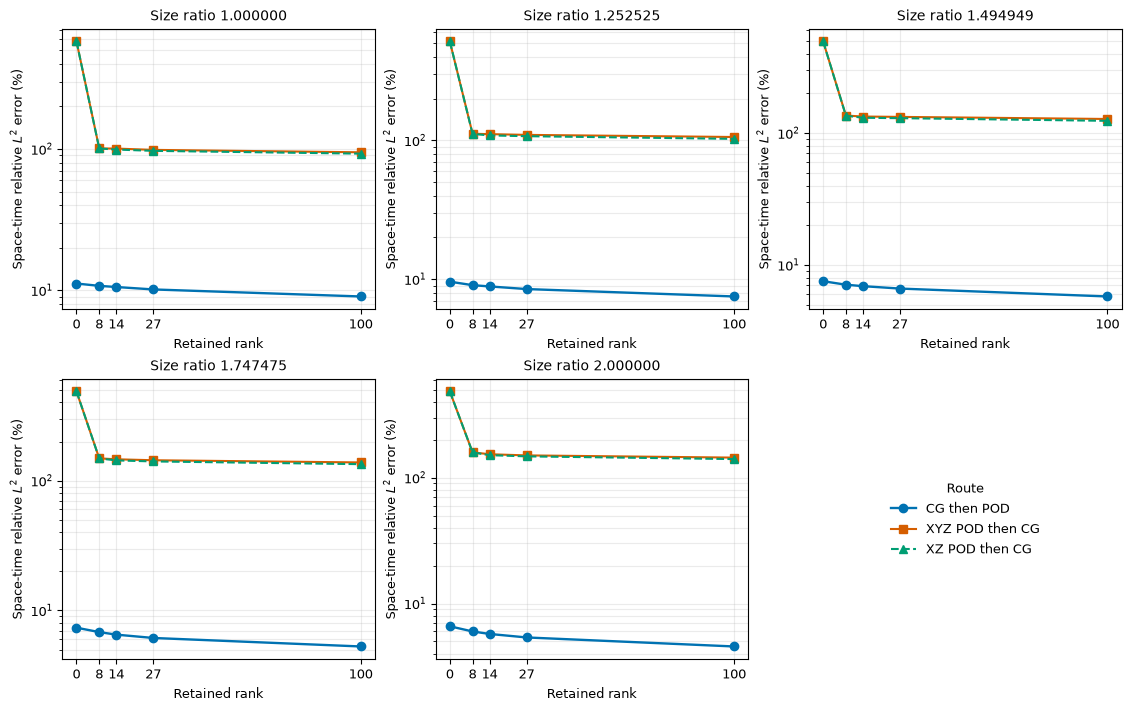

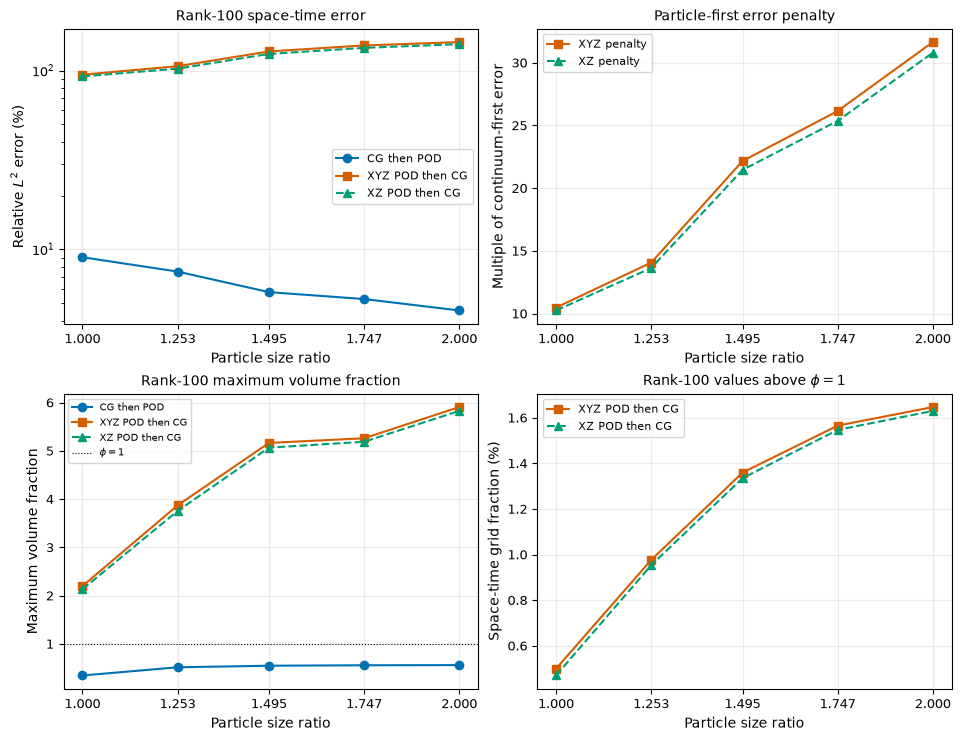

Saved figures:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/xz_particle_representation_sensitivity/xz_sensitivity_error_by_rank.pdf
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/xz_particle_representation_sensitivity/xz_sensitivity_error_by_rank.png
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/xz_particle_representation_sensitivity/xz_sensitivity_rank_100_summary.pdf
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/xz_particle_representation_sensitivity/xz_sensitivity_rank_100_summary.png


In [22]:
import matplotlib.pyplot as plt


CONTINUUM_COLOUR = "#0072B2"
XYZ_COLOUR = "#D55E00"
XZ_COLOUR = "#009E73"


RANK_FIGURE_PDF = (
    XZ_FIGURE_DIRECTORY
    / "xz_sensitivity_error_by_rank.pdf"
)

RANK_FIGURE_PNG = (
    XZ_FIGURE_DIRECTORY
    / "xz_sensitivity_error_by_rank.png"
)

SUMMARY_FIGURE_PDF = (
    XZ_FIGURE_DIRECTORY
    / "xz_sensitivity_rank_100_summary.pdf"
)

SUMMARY_FIGURE_PNG = (
    XZ_FIGURE_DIRECTORY
    / "xz_sensitivity_rank_100_summary.png"
)


with plt.rc_context(
    {
        "font.size": 9,
        "axes.labelsize": 9,
        "axes.titlesize": 10,
    }
):
    figure, axes = plt.subplots(
        2,
        3,
        figsize=(11.2, 7.0),
        constrained_layout=True,
    )

    axes = axes.ravel()

    for axis, case_row in zip(
        axes,
        case_plan.sort_values(
            "size_ratio"
        ).itertuples(index=False),
    ):
        case_results = (
            xz_comparison_by_rank.loc[
                xz_comparison_by_rank[
                    "case_id"
                ].eq(case_row.case_id)
            ]
            .sort_values("rank")
        )

        axis.semilogy(
            case_results["rank"],
            case_results[
                "continuum_first_error_percent"
            ],
            marker="o",
            linewidth=1.7,
            color=CONTINUUM_COLOUR,
            label="CG then POD",
        )

        axis.semilogy(
            case_results["rank"],
            case_results[
                "XYZ_particle_error_percent"
            ],
            marker="s",
            linewidth=1.5,
            color=XYZ_COLOUR,
            label="XYZ POD then CG",
        )

        axis.semilogy(
            case_results["rank"],
            case_results[
                "XZ_particle_error_percent"
            ],
            marker="^",
            linewidth=1.5,
            linestyle="--",
            color=XZ_COLOUR,
            label="XZ POD then CG",
        )

        axis.set_title(
            f"Size ratio {case_row.size_ratio:.6f}"
        )

        axis.set_xlabel(
            "Retained rank"
        )

        axis.set_ylabel(
            r"Space-time relative $L^2$ error (%)"
        )

        axis.set_xticks(
            SELECTED_RANKS
        )

        axis.grid(
            True,
            which="both",
            alpha=0.25,
        )


    # Use the otherwise empty sixth panel
    # for a shared route legend.
    handles, labels = (
        axes[0].get_legend_handles_labels()
    )

    axes[-1].axis("off")

    axes[-1].legend(
        handles,
        labels,
        loc="center",
        frameon=False,
        title="Route",
        fontsize=9,
    )


    figure.savefig(
        RANK_FIGURE_PDF,
        bbox_inches="tight",
    )

    figure.savefig(
        RANK_FIGURE_PNG,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


size_ratios = (
    rank_100_final_summary[
        "size_ratio"
    ].to_numpy()
)


with plt.rc_context(
    {
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
    }
):
    figure, axes = plt.subplots(
        2,
        2,
        figsize=(9.5, 7.3),
        constrained_layout=True,
    )

    axes[0, 0].semilogy(
        size_ratios,
        rank_100_final_summary[
            "continuum_first_error_percent"
        ],
        marker="o",
        color=CONTINUUM_COLOUR,
        label="CG then POD",
    )

    axes[0, 0].semilogy(
        size_ratios,
        rank_100_final_summary[
            "XYZ_particle_error_percent"
        ],
        marker="s",
        color=XYZ_COLOUR,
        label="XYZ POD then CG",
    )

    axes[0, 0].semilogy(
        size_ratios,
        rank_100_final_summary[
            "XZ_particle_error_percent"
        ],
        marker="^",
        linestyle="--",
        color=XZ_COLOUR,
        label="XZ POD then CG",
    )

    axes[0, 0].set_title(
        "Rank-100 space-time error"
    )

    axes[0, 0].set_ylabel(
        r"Relative $L^2$ error (%)"
    )

    axes[0, 0].legend(
        fontsize=8,
    )


    axes[0, 1].plot(
        size_ratios,
        (
            rank_100_final_summary[
                "XYZ_particle_error_percent"
            ]
            / rank_100_final_summary[
                "continuum_first_error_percent"
            ]
        ),
        marker="s",
        color=XYZ_COLOUR,
        label="XYZ penalty",
    )

    axes[0, 1].plot(
        size_ratios,
        rank_100_final_summary[
            "XZ_to_continuum_error_ratio"
        ],
        marker="^",
        linestyle="--",
        color=XZ_COLOUR,
        label="XZ penalty",
    )

    axes[0, 1].set_title(
        "Particle-first error penalty"
    )

    axes[0, 1].set_ylabel(
        "Multiple of continuum-first error"
    )

    axes[0, 1].legend(
        fontsize=8,
    )


    axes[1, 0].plot(
        size_ratios,
        rank_100_final_summary[
            "continuum_maximum_phi"
        ],
        marker="o",
        color=CONTINUUM_COLOUR,
        label="CG then POD",
    )

    axes[1, 0].plot(
        size_ratios,
        rank_100_final_summary[
            "XYZ_maximum_phi"
        ],
        marker="s",
        color=XYZ_COLOUR,
        label="XYZ POD then CG",
    )

    axes[1, 0].plot(
        size_ratios,
        rank_100_final_summary[
            "XZ_maximum_phi"
        ],
        marker="^",
        linestyle="--",
        color=XZ_COLOUR,
        label="XZ POD then CG",
    )

    axes[1, 0].axhline(
        1.0,
        color="black",
        linewidth=0.8,
        linestyle=":",
        label=r"$\phi=1$",
    )

    axes[1, 0].set_title(
        "Rank-100 maximum volume fraction"
    )

    axes[1, 0].set_ylabel(
        "Maximum volume fraction"
    )

    axes[1, 0].legend(
        fontsize=7,
    )


    axes[1, 1].plot(
        size_ratios,
        rank_100_final_summary[
            "XYZ_fraction_phi_gt_one_percent"
        ],
        marker="s",
        color=XYZ_COLOUR,
        label="XYZ POD then CG",
    )

    axes[1, 1].plot(
        size_ratios,
        rank_100_final_summary[
            "XZ_fraction_phi_gt_one_percent"
        ],
        marker="^",
        linestyle="--",
        color=XZ_COLOUR,
        label="XZ POD then CG",
    )

    axes[1, 1].set_title(
        r"Rank-100 values above $\phi=1$"
    )

    axes[1, 1].set_ylabel(
        "Space-time grid fraction (%)"
    )

    axes[1, 1].legend(
        fontsize=8,
    )


    for axis in axes.ravel():
        axis.set_xlabel(
            "Particle size ratio"
        )

        axis.set_xticks(
            size_ratios
        )

        axis.grid(
            True,
            alpha=0.25,
        )


    figure.savefig(
        SUMMARY_FIGURE_PDF,
        bbox_inches="tight",
    )

    figure.savefig(
        SUMMARY_FIGURE_PNG,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


print("Saved figures:")

for path in [
    RANK_FIGURE_PDF,
    RANK_FIGURE_PNG,
    SUMMARY_FIGURE_PDF,
    SUMMARY_FIGURE_PNG,
]:
    print(path)


assert all(
    path.is_file()
    for path in [
        RANK_FIGURE_PDF,
        RANK_FIGURE_PNG,
        SUMMARY_FIGURE_PDF,
        SUMMARY_FIGURE_PNG,
    ]
)

In [23]:
XZ_AGGREGATE_MANIFEST_PATH = (
    XZ_TABLE_DIRECTORY
    / "xz_particle_representation_sensitivity_manifest.json"
)


aggregate_artifacts = {
    "master_field_csv":
        MASTER_FIELD_CSV,
    "master_particle_csv":
        MASTER_PARTICLE_CSV,
    "master_energy_csv":
        MASTER_ENERGY_CSV,
    "comparison_by_rank_csv":
        COMPARISON_BY_RANK_CSV,
    "rank_100_summary_csv":
        RANK_100_SUMMARY_CSV,
    "regression_summary_csv":
        REGRESSION_SUMMARY_CSV,
    "rank_figure_pdf":
        RANK_FIGURE_PDF,
    "rank_figure_png":
        RANK_FIGURE_PNG,
    "summary_figure_pdf":
        SUMMARY_FIGURE_PDF,
    "summary_figure_png":
        SUMMARY_FIGURE_PNG,
}


xz_aggregate_manifest = {
    "schema_version": 1,
    "notebook":
        "13_xz_particle_representation_sensitivity.ipynb",
    "source_notebook_12_manifest": {
        "relative_path":
            str(
                AGGREGATE_MANIFEST_PATH.relative_to(
                    REPO_ROOT
                )
            ),
        "sha256":
            sha256_file(
                AGGREGATE_MANIFEST_PATH
            ),
    },
    "experiment": {
        "case_count": 5,
        "size_ratios": [
            float(value)
            for value in size_ratios
        ],
        "ranks": list(SELECTED_RANKS),
        "training_snapshots_per_case": 101,
        "validation_snapshots_per_case": 99,
        "particle_representation":
            "labelled XZ coordinates",
        "comparison_representations": [
            "labelled XYZ coordinates",
            "small-species XZ volume fraction",
        ],
        "validation_type":
            "blocked cycle-2 oracle projection",
        "lucy_cutoff":
            float(LUCY_CUTOFF),
        "grid_shape": [
            len(reference_x),
            len(reference_z),
        ],
    },
    "regression": {
        "maximum_rank_zero_metric_difference":
            float(
                regression_summary[
                    "maximum_rank_zero_difference"
                ].max()
            ),
        "maximum_natural_cycle_error_difference":
            float(
                regression_summary[
                    "natural_cycle_error_difference"
                ].max()
            ),
    },
    "rank_100_findings": {
        "xz_error_range_percent": [
            float(
                rank_100_xz_errors.min()
            ),
            float(
                rank_100_xz_errors.max()
            ),
        ],
        "xz_error_reduction_vs_xyz_range_percent": [
            float(
                rank_100_xz_reductions.min()
            ),
            float(
                rank_100_xz_reductions.max()
            ),
        ],
        "xz_to_continuum_error_ratio_range": [
            float(
                rank_100_xz_penalties.min()
            ),
            float(
                rank_100_xz_penalties.max()
            ),
        ],
        "xz_error_strictly_increases":
            bool(
                np.all(
                    np.diff(
                        rank_100_xz_errors
                    ) > 0
                )
            ),
        "xz_to_continuum_penalty_strictly_increases":
            bool(
                np.all(
                    np.diff(
                        rank_100_xz_penalties
                    ) > 0
                )
            ),
    },
    "case_manifests": {
        case_id: {
            "relative_path":
                str(
                    checkpoint[
                        "paths"
                    ]["manifest"].relative_to(
                        REPO_ROOT
                    )
                ),
            "sha256":
                sha256_file(
                    checkpoint[
                        "paths"
                    ]["manifest"]
                ),
        }
        for case_id, checkpoint
        in all_xz_checkpoints.items()
    },
    "aggregate_artifacts": {
        name: {
            "relative_path":
                str(
                    path.relative_to(
                        REPO_ROOT
                    )
                ),
            "sha256":
                sha256_file(path),
        }
        for name, path
        in aggregate_artifacts.items()
    },
}


temporary_manifest_path = (
    XZ_AGGREGATE_MANIFEST_PATH
    .with_suffix(".tmp.json")
)

with temporary_manifest_path.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        xz_aggregate_manifest,
        handle,
        indent=2,
    )

temporary_manifest_path.replace(
    XZ_AGGREGATE_MANIFEST_PATH
)


with XZ_AGGREGATE_MANIFEST_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    recorded_manifest = json.load(handle)


integrity_records = []

for case_id, record in (
    recorded_manifest[
        "case_manifests"
    ].items()
):
    path = (
        REPO_ROOT
        / record["relative_path"]
    )

    integrity_records.append(
        {
            "artifact":
                f"case manifest: {case_id}",
            "exists": path.is_file(),
            "hash_matches": (
                path.is_file()
                and sha256_file(path)
                == record["sha256"]
            ),
        }
    )

for artifact_name, record in (
    recorded_manifest[
        "aggregate_artifacts"
    ].items()
):
    path = (
        REPO_ROOT
        / record["relative_path"]
    )

    integrity_records.append(
        {
            "artifact": artifact_name,
            "exists": path.is_file(),
            "hash_matches": (
                path.is_file()
                and sha256_file(path)
                == record["sha256"]
            ),
        }
    )


integrity_audit = pd.DataFrame(
    integrity_records
)

print("Final XZ integrity audit:")

display(integrity_audit)

print(
    "Recorded artifacts:",
    len(integrity_audit),
)

print(
    "Aggregate manifest:",
    XZ_AGGREGATE_MANIFEST_PATH,
)

print(
    "Aggregate manifest SHA-256:",
    sha256_file(
        XZ_AGGREGATE_MANIFEST_PATH
    ),
)


assert recorded_manifest["schema_version"] == 1
assert len(integrity_audit) == 15
assert integrity_audit["exists"].all()
assert integrity_audit["hash_matches"].all()

assert (
    recorded_manifest[
        "regression"
    ][
        "maximum_rank_zero_metric_difference"
    ]
    < 1e-10
)

assert (
    recorded_manifest[
        "regression"
    ][
        "maximum_natural_cycle_error_difference"
    ]
    < 1e-10
)

print(
    "\nAll XZ sensitivity artifacts "
    "passed the final integrity audit:",
    True,
)

Final XZ integrity audit:


,artifact,exists,hash_matches
0,case manifest: ratio_1_000000_num_1,True,True
1,case manifest: ratio_1_252525_num_26,True,True
2,case manifest: ratio_1_494949_num_50,True,True
3,case manifest: ratio_1_747475_num_75,True,True
4,case manifest: ratio_2_000000_num_100,True,True
5,master_field_csv,True,True
6,master_particle_csv,True,True
7,master_energy_csv,True,True
8,comparison_by_rank_csv,True,True
9,rank_100_summary_csv,True,True


Recorded artifacts: 15
Aggregate manifest: /Users/rallen/Documents/msc-rom-particle-systems/results/tables/xz_particle_representation_sensitivity/xz_particle_representation_sensitivity_manifest.json
Aggregate manifest SHA-256: 389bb1a53975fe098c7da908b5886adfb42f13237f6c6464b3c170f7b6d0cfce

All XZ sensitivity artifacts passed the final integrity audit: True


## XZ sensitivity conclusion

Removing the transverse \(y\)-coordinate produces a small, consistent
improvement in the particle-first reconstruction, but it does not materially
change the route-order comparison.

At rank 100, the XZ particle-first space-time errors range from approximately
\(92.69\%\) to \(140.36\%\). These are between approximately \(2.19\%\) and
\(3.19\%\) lower than the corresponding XYZ particle-first errors. However, the
XZ particle-first errors remain approximately \(10.25\) to \(30.80\) times the
continuum-first errors, and this penalty increases strictly with particle size
ratio.

The XZ reconstructions also remain physically problematic. Their maximum
small-particle volume fractions increase from approximately \(2.13\) to \(5.83\),
while approximately \(0.47\%\) to \(1.63\%\) of the space-time grid exceeds
\(\phi=1\).

Therefore, the poor performance of particle-coordinate POD cannot be explained
primarily by spending retained modes on transverse motion that is later
discarded during coarse-graining. The main limitation is instead associated
with the linear reduction of labelled particle coordinates in a rotating,
advective and mixing system.

This sensitivity study strengthens, but does not universalise, the conclusion
of Notebook 12. It applies to labelled linear XYZ and XZ coordinate POD, the
five selected parameter cases, the tested ranks and the stated
coarse-graining configuration. It does not rule out alternative
permutation-invariant, transport-based or nonlinear particle representations.